# Training, Validation and Testing: Generalisation, Overfitting and Model Selection

Practical 3 ended with a warning. As the polynomial degree went up, the **training error kept falling** while the
**test error turned back up**, so "pick the model with the smallest training error" always picked the *worst*
model. We could see the true test error there only because we had generated the data ourselves and could draw
fresh samples whenever we liked. The last line of that practical was: *in real life you must hold some back.*

This practical is about **how to hold data back properly**. With a real dataset you get one fixed table of $n$
rows and no more. From that one table you have to do three different jobs:

1. **train** a model (learn its parameters),
2. **choose** between models and hyper-parameters (model selection),
3. **report** how well the final model will do on data that nobody has seen yet (model assessment).

Using the same rows for more than one of these jobs is the most common mistake in applied machine learning, and it
always makes the model look better than it really is. The practical has eight parts:

0. **Two standard datasets** and the `fit` / `predict` interface of scikit-learn models.
1. **The hold-out method** and the untouched test set: written from scratch and checked against `train_test_split`.
2. **Hold-out validation**: training error versus validation error, and how noisy a single split is.
3. **k-fold cross-validation** from scratch, checked against `KFold` and `cross_validate`.
4. **Stratified k-fold cross-validation** from scratch, checked against `StratifiedKFold`.
5. **Underfitting and overfitting**: training and validation error against model complexity, for a classifier and
   for a regressor, and the point of best generalisation.
6. **Learning curves**: error against the size of the training set.
7. **Model selection with the validation data only**, and one final, unbiased error on the untouched test set.

**What is new in the toolbox.** In Practicals 1 to 3 every model was written by hand in NumPy. Here the models
themselves (k-nearest neighbours, logistic regression, decision trees) come from **scikit-learn**, because the
subject of this practical is not the models but the **procedures around them**. Every one of those procedures
(splitting, cross-validation, stratification, learning curves, model selection) is written **from scratch** and then
checked against scikit-learn's own implementation. When our numbers and the library's numbers agree exactly, we
know we have understood what the library does.

**Vocabulary used throughout**

| term | meaning in this notebook |
|---|---|
| **training set** | the rows a model learns its parameters from |
| **validation set** | rows held back to *compare* models and *choose* hyper-parameters; never used to fit parameters |
| **test set** | rows locked away at the start and used **exactly once**, at the very end, to report the error of the one final model |
| **development set** | training + validation together: everything except the test set |
| **parameter** | a number learned by `fit` (the weights $w$ of Practical 1, the means and covariances of Practicals 2 and 3) |
| **hyper-parameter** | a setting *we* choose before `fit` (the $k$ of k-NN, a polynomial degree, a tree depth) |
| **training error** | the error of a model on the rows it was fitted to |
| **validation error** | the error on held-back rows that we use for choosing |
| **generalisation error** | the error on new data from the same source: the number we actually care about. Practical 3 called it the *risk* |
| **underfitting** | the model is too simple: training *and* validation error are both high |
| **overfitting** | the model is too flexible: training error is low, validation error is much higher |

**Notation**

| symbol | meaning |
|---|---|
| $n$, $d$ | number of rows (samples) and number of columns (features) of $X$, as in Practical 1 |
| $L(y, \hat y)$ | loss: 0–1 loss for classification, squared loss for regression (Practical 3) |
| $\text{Err}(\hat f) = E\big[L(Y, \hat f(X))\big]$ | generalisation error of a *trained* model $\hat f$: its average loss on new data |
| $K$ | number of **folds** in cross-validation (capital, so it is never confused with the $k$ of k-NN) |
| $\text{CV}_K = \frac{1}{K}\sum_{j=1}^{K} \text{Err}_j$ | the $K$-fold cross-validation estimate: the average of the $K$ fold errors |

In [1]:
import numpy as np                      # arrays, random numbers, all the numerical work
import pandas as pd                     # tables, so results print with readable labels
import matplotlib.pyplot as plt         # every plot in this notebook
from matplotlib.colors import ListedColormap        # two-colour maps for decision-region plots

from sklearn.datasets import load_breast_cancer, load_diabetes, load_wine    # standard public datasets
from sklearn.base import clone                       # makes a fresh, untrained copy of a model
from sklearn.pipeline import make_pipeline, Pipeline # chain "standardise, then model" into one object
from sklearn.preprocessing import StandardScaler     # rescales every feature to mean 0, std 1
from sklearn.neighbors import KNeighborsClassifier   # k-nearest-neighbour classifier (Practical 3)
from sklearn.linear_model import LogisticRegression  # logistic regression (Practical 3)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor   # decision trees

# Library versions of everything we build from scratch. They are used ONLY to check our own code.
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                     cross_validate, learning_curve, GridSearchCV)

%matplotlib inline

rng = np.random.default_rng(42)                    # one seeded generator for general random numbers
np.set_printoptions(precision=4, suppress=True)    # 4 decimals, no scientific notation
pd.set_option("display.precision", 4)              # same idea for DataFrames
plt.rcParams["figure.figsize"] = (6, 4)            # default plot size in inches
plt.rcParams["figure.dpi"] = 300                   # default resolution

**Line by line**

- The first three imports are the same as in every practical so far.
- `from sklearn... import ...` : **scikit-learn** (imported as `sklearn`) is the standard machine-learning library for
  Python. We import only the handful of pieces we need, each with a comment saying what it is for. If the import
  fails, install it once with `uv add scikit-learn` in a terminal.
- `load_breast_cancer`, `load_diabetes`, `load_wine` : three classic public datasets that are **shipped inside**
  scikit-learn, so they load instantly and need no internet connection.
- The last import block brings in the library's own splitting and cross-validation tools. Read the comment above it:
  we never use them to *do* the work, only to **check** the functions we write ourselves.
- `rng = np.random.default_rng(42)` : the seeded generator from Practicals 2 and 3. As before, run the notebook from
  top to bottom (*Kernel → Restart & Run All*) to get exactly the numbers quoted in the text.
- `figure.dpi = 150` : a little lower than in Practical 3, which keeps the notebook file small. Raise it if you want
  sharper figures.

---
## Part 0: Two standard datasets and the model interface

### 0a. Classification: the Breast Cancer Wisconsin (Diagnostic) dataset

Our main dataset comes from the **UCI Machine Learning Repository** and has been a standard benchmark since the
1990s. Each row is one breast tumour. A fine-needle sample of the tumour was photographed under a microscope, and
for the cell nuclei in the image ten properties were measured (radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension). For each property the dataset stores the
**mean** over the nuclei, its **standard error**, and the **worst** (largest) value, giving $10 \times 3 = 30$
numeric features. The label says whether the tumour was **malignant** or **benign**.

In the language of Practical 1: a feature matrix $X$ of order $n \times d = 569 \times 30$, a target vector $y$ of
length 569, a 30-dimensional feature space, and a **binary classification** problem.

In [2]:
cancer = load_breast_cancer()            # a "Bunch": a dictionary-like object holding the whole dataset
X_bc = cancer.data                       # (569, 30) feature matrix, one tumour per row
y_bc = cancer.target                     # (569,) labels: 0 = malignant, 1 = benign
feature_names_bc = cancer.feature_names  # the 30 column names
class_names_bc = cancer.target_names     # array(['malignant', 'benign'])

print("feature matrix X :", X_bc.shape)
print("target vector y  :", y_bc.shape)
print("classes          :", dict(enumerate(class_names_bc)))
print("class counts     :", np.bincount(y_bc))
print(f"fraction malignant = {np.mean(y_bc == 0):.4f}")
print(f"\nfeature scales differ a lot:  'mean area' ranges from {X_bc[:, 3].min():.0f} to {X_bc[:, 3].max():.0f},"
      f"  'mean smoothness' from {X_bc[:, 4].min():.3f} to {X_bc[:, 4].max():.3f}")

df_bc = pd.DataFrame(X_bc, columns=feature_names_bc)        # the matrix as a labelled table
df_bc["diagnosis"] = class_names_bc[y_bc]                    # add the label as a readable word
df_bc.iloc[:5, [0, 1, 2, 3, 4, 20, 21, 27, 30]]              # first 5 rows, a few of the columns

feature matrix X : (569, 30)
target vector y  : (569,)
classes          : {0: np.str_('malignant'), 1: np.str_('benign')}
class counts     : [212 357]
fraction malignant = 0.3726

feature scales differ a lot:  'mean area' ranges from 144 to 2501,  'mean smoothness' from 0.053 to 0.163


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,worst radius,worst texture,worst concave points,diagnosis
0,17.99,10.38,122.80,1001.0,0.1184,25.38,17.33,0.2654,malignant
1,20.57,17.77,132.90,1326.0,0.0847,24.99,23.41,0.1860,malignant
2,19.69,21.25,130.00,1203.0,0.1096,23.57,25.53,0.2430,malignant
3,11.42,20.38,77.58,386.1,0.1425,14.91,26.50,0.2575,malignant
4,20.29,14.34,135.10,1297.0,0.1003,22.54,16.67,0.1625,malignant


**Line by line**

- `load_breast_cancer()` returns a **Bunch**, which behaves like a dictionary whose keys can also be read as
  attributes: `cancer.data` is the same as `cancer["data"]`.
- `cancer.target` stores the labels as integers. **Careful with the coding:** 0 means *malignant* and 1 means
  *benign*. The error rate does not care which class is called 0, but it matters when you read a confusion table.
- `np.bincount(y_bc)` : counts how many 0s and how many 1s (Practical 2). The classes are **unbalanced**: 212
  malignant against 357 benign, so about 37% malignant. Keep this number in mind; it is the reason for Part 4.
- `class_names_bc[y_bc]` : uses the 569 integer labels as indices into the two-word array, turning each 0 into
  `'malignant'` and each 1 into `'benign'` (fancy indexing, Practical 3).
- `df_bc.iloc[:5, [0, 1, ...]]` : `iloc` selects by **position**: the first 5 rows and the listed column positions.
  Column 30 is the `diagnosis` column we just added.

**Reading the output.** Look at the printed ranges: *mean area* runs into the thousands while *mean smoothness* is a
small fraction. Any method that measures **distances** between rows, such as k-NN, would be completely dominated
by the area column unless every feature is first put on a common scale. That is why every k-NN model below starts
with a `StandardScaler` (section 0c).

### 0b. Regression: the Diabetes dataset

Our second dataset, from Efron, Hastie, Johnstone and Tibshirani's 2004 paper *Least Angle Regression*, is the
standard small regression benchmark. Each row is one diabetes patient. The ten features are age, sex, body-mass
index (`bmi`), average blood pressure (`bp`) and six blood-serum measurements (`s1` to `s6`). The target is a
number measuring **how far the disease progressed one year later**. So $X$ is $442 \times 10$ and $y$ is a real
number: a **regression** problem.

In [3]:
diabetes = load_diabetes()
X_db = diabetes.data                     # (442, 10) feature matrix, one patient per row
y_db = diabetes.target                   # (442,) disease progression after one year
feature_names_db = diabetes.feature_names

print("feature matrix X :", X_db.shape)
print("target vector y  :", y_db.shape)
print(f"target: mean = {y_db.mean():.1f}, variance = {y_db.var():.1f}, range = {y_db.min():.0f} to {y_db.max():.0f}")

df_db = pd.DataFrame(X_db, columns=feature_names_db)
df_db["progression"] = y_db
df_db.head()

feature matrix X : (442, 10)
target vector y  : (442,)
target: mean = 152.1, variance = 5929.9, range = 25 to 346


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0


**Line by line**

- The same pattern as 0a: `.data` is the feature matrix and `.target` the target vector.
- `y_db.var()` : the variance of the target. Remember this number (about 5930). A model that ignores the features and
  always predicts the average progression has a mean squared error equal to this variance, so it is the **baseline**
  every regression model below must beat.

**Reading the output.** The features look strange: small numbers around zero, and even `sex` is not 0/1. The
creators of the dataset have already **centred and rescaled** every column (each column has mean 0 and the same
total spread). That is convenient for us, but note that it was done using *all* 442 rows. For this practical it
changes nothing, because it is a fixed recipe applied equally to every row. In your own projects you must compute
any scaling from the training rows only; section 0c shows how.

### 0c. The two error measures, and the `fit` / `predict` interface

Every procedure in this practical needs to measure an error. We use exactly the losses of Practical 3:

- **classification error rate** = the fraction of wrong predictions (the average 0–1 loss),
- **mean squared error (MSE)** = the average squared difference between prediction and truth (the average squared loss).

Every scikit-learn model follows the same two-step interface:

- `model.fit(X, y)` learns the parameters from the rows it is given,
- `model.predict(X)` returns one prediction per row.

A **pipeline** chains several steps into one model. `make_pipeline(StandardScaler(), KNeighborsClassifier(k))` is a
single object that, when you call `fit`, first learns the mean and standard deviation of every column **from the
training rows only** and rescales them, and then fits k-NN on the rescaled rows. When you call `predict`, it
rescales the new rows with the *training* mean and standard deviation and then predicts. This matters a lot later:
it guarantees that no information from validation or test rows ever leaks into the scaling.

In [4]:
def error_rate(y_true, y_pred):
    '''Classification error: the fraction of predictions that are wrong (average 0-1 loss).'''
    return np.mean(y_true != y_pred)


def mse(y_true, y_pred):
    '''Regression error: the mean squared error (average squared loss).'''
    return np.mean((y_true - y_pred) ** 2)


def make_knn(k):
    '''k-NN classifier that first standardises every feature, packaged as ONE model.'''
    return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))


demo = make_knn(5)                                 # an untrained 5-NN pipeline
demo.fit(X_bc[:400], y_bc[:400])                   # learn from the first 400 rows only
pred_demo = demo.predict(X_bc[400:])               # predict the remaining 169 rows

print(demo)                                        # shows the two steps of the pipeline
print("\nfirst 10 predictions :", pred_demo[:10])
print("first 10 true labels :", y_bc[400:410])
print(f"\nerror rate on the 169 rows the model did NOT see : {error_rate(y_bc[400:], pred_demo):.4f}")
print(f"error rate on the 400 rows it WAS trained on      : {error_rate(y_bc[:400], demo.predict(X_bc[:400])):.4f}")

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsclassifier', KNeighborsClassifier())])

first 10 predictions : [0 1 1 1 1 1 1 1 0 1]
first 10 true labels : [0 1 1 1 1 1 1 1 0 1]

error rate on the 169 rows the model did NOT see : 0.0355
error rate on the 400 rows it WAS trained on      : 0.0275


**Line by line**

- `error_rate` : `y_true != y_pred` is a boolean array (`True` where the prediction is wrong), and the mean of a
  boolean array is the fraction of `True`s. The same one-liner as in Practical 3.
- `mse` : the average squared miss, exactly as in Practical 3.
- `make_knn(k)` : a small **factory** function that returns a brand-new, untrained pipeline every time it is called.
  We will create hundreds of models, so it saves typing and keeps every k-NN model identical apart from $k$.
- `demo.fit(X_bc[:400], y_bc[:400])` : trains on rows 0 to 399. For k-NN "training" is cheap: the scaler stores the
  column means and standard deviations, and k-NN stores the (scaled) training rows.
- `demo.predict(X_bc[400:])` : for each of the 169 remaining rows, finds its 5 nearest training rows and takes a
  majority vote.
- `print(demo)` : shows the pipeline's two named steps and their settings.

**Reading the output.** We have just done the simplest possible **hold-out** evaluation: train on some rows, measure
the error on other rows. The two numbers are already different: the error on the rows the model was trained on is
lower than the error on unseen rows. The rest of this practical makes this crude experiment rigorous. Notice also
one weakness straight away: we simply took *the first* 400 rows. If the file happened to be sorted (say, all
malignant tumours first), the two parts would come from different populations. The first rule of splitting is
therefore: **shuffle first**.

---
## Part 1: The hold-out method and the untouched test set

### 1a. Three jobs, three sets of rows

A useful picture is a student preparing for a university exam:

| data | exam analogy | what it is used for | how often it is looked at |
|---|---|---|---|
| **training set** | the textbook and solved examples | fitting the parameters of a model | as often as you like |
| **validation set** | mock tests | comparing models, choosing hyper-parameters, deciding when to stop | many times, but *only* to choose |
| **test set** | the final exam paper | reporting the error of the one model you finally chose | **once**, at the very end |

If the final exam paper leaks and a student practises on it, their exam mark no longer says anything about what
they have learned. The same happens to a model: **every time you look at the test error and change something in
response, the test set becomes a little more like a validation set**, and the reported number becomes a little
more optimistic. So the very first thing we do with a new dataset, before any plotting, any modelling, any
choosing, is to cut off the test set and lock it away.

The **hold-out method** is the simplest way to cut a dataset into two parts:

1. shuffle the row numbers $0, 1, \dots, n-1$ into a random order,
2. the first $\lceil f \cdot n \rceil$ of the shuffled numbers become the held-out part (a fraction $f$ of the data),
3. the rest become the training part.

### 1b. The hold-out split from scratch, checked against `train_test_split`

In [ ]:
def holdout_split(n, test_frac, seed):
    '''Hold-out method: shuffle the row numbers 0..n-1, then cut them into a training part and a held-out part.

    n         : number of rows in the dataset
    test_frac : fraction of rows to hold out (for example 0.2)
    seed      : integer that fixes the shuffle, so the split can be reproduced
    returns   : (train_idx, test_idx), two arrays of row numbers
    '''
    perm = np.random.RandomState(seed).permutation(n)   # step 1: the numbers 0..n-1 in random order
    n_test = int(np.ceil(test_frac * n))                # step 2: size of the held-out part, rounded UP
    test_idx = perm[:n_test]                            #         the first n_test shuffled numbers
    train_idx = perm[n_test:]                           # step 3: all the others
    return train_idx, test_idx


train_idx, test_idx = holdout_split(len(y_bc), 0.2, seed=0)

print("training rows :", len(train_idx), "   held-out rows :", len(test_idx))
print("first 10 held-out row numbers:", test_idx[:10])
print("no row in both parts      :", len(np.intersect1d(train_idx, test_idx)) == 0)
print("every row in exactly one  :", np.array_equal(np.sort(np.concatenate([train_idx, test_idx])),
                                                    np.arange(len(y_bc))))

# the library check 
X_tr_lib, X_te_lib, y_tr_lib, y_te_lib = train_test_split(X_bc, y_bc, test_size=0.2, random_state=0)
print("\nsame training rows as train_test_split :", np.array_equal(X_bc[train_idx], X_tr_lib))
print("same held-out rows as train_test_split :", np.array_equal(X_bc[test_idx], X_te_lib))
print("same labels, in the same order         :", np.array_equal(y_bc[train_idx], y_tr_lib)
      and np.array_equal(y_bc[test_idx], y_te_lib))

training rows : 455    held-out rows : 114
first 10 held-out row numbers: [512 457 439 298  37 515 382 310 538 345]
no row in both parts      : True
every row in exactly one  : True

same training rows as train_test_split : True
same held-out rows as train_test_split : True
same labels, in the same order         : True


**Line by line**

- `np.random.RandomState(seed)` : an older style of NumPy random generator. We use it here, instead of the
  `default_rng` of Practicals 2 and 3, for one reason only: **scikit-learn uses `RandomState` internally**. By using the
  same generator with the same seed, our shuffle produces *exactly the same* order as the library's, which lets us
  check our code row by row rather than just "roughly".
- `.permutation(n)` : returns the numbers $0, 1, \dots, n-1$ in a random order. Every number appears exactly once, so
  nothing is lost and nothing is duplicated.
- `np.ceil(test_frac * n)` : $0.2 \times 569 = 113.8$, rounded **up** to 114. `int(...)` turns the float into an
  integer so it can be used for slicing.
- `perm[:n_test]` and `perm[n_test:]` : slicing, the first 114 shuffled row numbers and all the rest. Because they
  are two non-overlapping slices of one permutation, the two parts can never share a row.
- The two checks:
  - `np.intersect1d(a, b)` returns the numbers that appear in both arrays; an empty result means the parts are
    **disjoint**.
  - Joining both parts and sorting must give back exactly $0, 1, \dots, 568$: every row is used, exactly once.
- `train_test_split(X, y, test_size=0.2, random_state=0)` : the library's hold-out split. It returns four arrays,
  in the order train-X, test-X, train-y, test-y.
- `X_bc[train_idx]` : indexing the matrix with an array of row numbers picks those rows, in that order.
  `np.array_equal` is `True` only if two arrays have the same shape and every entry is equal.

**Reading the output.** All five checks print `True`. Our twelve-line function reproduces `train_test_split`
exactly: the same 114 rows are held out, in the same order. There is no magic in the library function; it is a
shuffle and a cut.

### 1c. Stratified hold-out: keeping the class proportions

A plain random split can, by bad luck, put noticeably more (or fewer) malignant tumours into the held-out part than
into the training part. With 114 held-out rows and a true malignant fraction of 0.37, the malignant fraction of a
random held-out part has a standard deviation of about $\sqrt{0.37 \times 0.63 / 114} \approx 0.045$, so values like
0.30 or 0.45 happen regularly.

A **stratified** split removes this source of noise. The recipe is simple: **do a hold-out split inside every class
separately**, then put the pieces back together. Every class then contributes the same fraction $f$ of its rows to
the held-out part, so the class proportions are (up to rounding) identical in both parts.

In [6]:
def stratified_holdout_split(y, test_frac, seed):
    '''Hold-out split that preserves the class proportions: split each class separately, then merge.

    y         : (n,) array of class labels
    returns   : (train_idx, test_idx), two arrays of row numbers
    '''
    rs = np.random.RandomState(seed)                          # one generator for all the shuffles below
    train_parts, test_parts = [], []
    for c in np.unique(y):                                    # one class at a time
        members = rs.permutation(np.flatnonzero(y == c))      # the row numbers of class c, in random order
        n_test_c = int(np.ceil(test_frac * len(members)))     # how many of them to hold out (rounded up)
        test_parts.append(members[:n_test_c])
        train_parts.append(members[n_test_c:])
    train_idx = rs.permutation(np.concatenate(train_parts))   # merge the classes and mix them up again
    test_idx = rs.permutation(np.concatenate(test_parts))
    return train_idx, test_idx


rows = []
for seed in range(6):                                          # six different random splits
    _, te_plain = holdout_split(len(y_bc), 0.2, seed)
    _, te_strat = stratified_holdout_split(y_bc, 0.2, seed)
    _, _, _, y_te_lib = train_test_split(X_bc, y_bc, test_size=0.2, random_state=seed, stratify=y_bc)
    rows.append({"seed": seed,
                 "plain hold-out": np.mean(y_bc[te_plain] == 0),          # fraction malignant in held-out part
                 "our stratified": np.mean(y_bc[te_strat] == 0),
                 "sklearn stratified": np.mean(y_te_lib == 0),
                 "held-out size (ours / sklearn)": f"{len(te_strat)} / {len(y_te_lib)}"})

spread = {"seed": "std over 1000 seeds",
          "plain hold-out": np.std([np.mean(y_bc[holdout_split(len(y_bc), 0.2, s)[1]] == 0) for s in range(1000)]),
          "our stratified": np.std([np.mean(y_bc[stratified_holdout_split(y_bc, 0.2, s)[1]] == 0) for s in range(1000)]),
          "sklearn stratified": np.nan, "held-out size (ours / sklearn)": ""}

print(f"fraction malignant in the WHOLE dataset: {np.mean(y_bc == 0):.4f}\n")
pd.DataFrame(rows + [spread]).set_index("seed")

fraction malignant in the WHOLE dataset: 0.3726



,plain hold-out,our stratified,sklearn stratified,held-out size (ours / sklearn)
seed,,,,
0,0.4123,0.3739,0.3684,115 / 114
1,0.3684,0.3739,0.3684,115 / 114
2,0.3947,0.3739,0.3684,115 / 114
3,0.3509,0.3739,0.3684,115 / 114
4,0.2982,0.3739,0.3684,115 / 114
5,0.4211,0.3739,0.3684,115 / 114
std over 1000 seeds,0.0384,0.0000,NaN,


**Line by line**

- `np.flatnonzero(y == c)` : the positions where the boolean array is `True`, i.e. the row numbers of class `c`.
- `rs.permutation(array)` : when given an array instead of a number, `permutation` returns a shuffled **copy** of that
  array. So `members` holds the row numbers of one class in random order.
- For each class we take the first $\lceil f \cdot n_c \rceil$ shuffled rows for the held-out part, exactly the rule
  of `holdout_split`, but applied within the class.
- `np.concatenate(test_parts)` : joins the per-class pieces. Without the final `rs.permutation(...)` all malignant
  rows would come first and all benign rows after them. A sorted order like that is a trap for any later procedure
  that takes "the first so many rows", so we mix them again.
- `train_test_split(..., stratify=y_bc)` : the library's stratified hold-out.
- The last row of the table is the **standard deviation** of the malignant fraction over 1000 different seeds, which
  measures how much each method wobbles from split to split.

**Reading the table.**

- The **plain** hold-out gives a different malignant fraction for every seed: from 0.298 (seed 4) to 0.421 (seed 5)
  in these six rows, spread around the true 0.3726. Over 1000 seeds the standard deviation is 0.038, close to the
  0.045 predicted above (slightly smaller, because drawing *without* replacement from only 569 rows varies a little
  less than the simple formula assumes).
- **Both stratified methods** hit the true proportion every time, to within one row. Our split always holds out
  exactly 43 malignant tumours out of 115 (0.3739), whatever the seed, so over 1000 seeds its standard deviation is
  **exactly zero**: stratification has removed this source of randomness completely. Only *which* 43 malignant rows
  are chosen changes with the seed.
- The two stratified methods do **not** pick identical rows. Look at the size column: we round up *within each
  class* ($\lceil 42.4 \rceil + \lceil 71.4 \rceil = 43 + 72 = 115$), while scikit-learn first fixes the total at
  $\lceil 113.8 \rceil = 114$ and then shares those 114 places between the classes. Both are valid stratified splits;
  they differ by one row. This is the verification we can do here: **the same class proportions**, not the same rows.
  (In Part 4 we will reproduce the library's *stratified k-fold* exactly, row for row.)

### 1d. Lock away the test sets

Now we cut off 20% of each dataset as its **test set**. For the classification data we use our stratified split,
so the test set has the same malignant fraction as the rest. For the regression data there are no classes, so we
use the plain hold-out split.

**From this cell until section 7e, `X_test`, `y_test`, `Xr_test` and `yr_test` are never used.** Everything in
Parts 2 to 7d works on the development sets only.

In [7]:
SEED_TEST = 2026                                                  # fixed once, never changed afterwards

# classification: stratified 80 / 20
dev_idx, test_idx = stratified_holdout_split(y_bc, 0.2, seed=SEED_TEST)
X_dev, y_dev = X_bc[dev_idx], y_bc[dev_idx]                       # development set: train + validation
X_test, y_test = X_bc[test_idx], y_bc[test_idx]                   # LOCKED until section 7e

# regression: plain 80 / 20 (no classes to stratify on)
dev_idx_r, test_idx_r = holdout_split(len(y_db), 0.2, seed=SEED_TEST)
Xr_dev, yr_dev = X_db[dev_idx_r], y_db[dev_idx_r]                 # development set for regression
Xr_test, yr_test = X_db[test_idx_r], y_db[test_idx_r]             # LOCKED until Exercise 3

pd.DataFrame({
    "rows": [len(y_dev), len(y_test), len(yr_dev), len(yr_test)],
    "fraction malignant / mean target": [np.mean(y_dev == 0), np.mean(y_test == 0), yr_dev.mean(), yr_test.mean()],
}, index=["Breast Cancer: development", "Breast Cancer: TEST (locked)",
          "Diabetes: development", "Diabetes: TEST (locked)"])

,rows,fraction malignant / mean target
Breast Cancer: development,454,0.3722
Breast Cancer: TEST (locked),115,0.3739
Diabetes: development,353,152.7280
Diabetes: TEST (locked),89,149.7753


**Line by line**

- `SEED_TEST = 2026` : the seed for the test split is written in capitals and set once. If you changed it after
  seeing results, you would be choosing the test set, which is a (sneaky) way of looking at it.
- `X_bc[dev_idx], y_bc[dev_idx]` : the **same** row numbers must be used for `X` and for `y`, otherwise the labels
  would no longer belong to their rows.
- The table is only a record of sizes and proportions. Looking at the *labels* of the test set in this summary is
  harmless because we choose nothing based on it.

**Reading the table.** 454 development rows and 115 test rows for the classification problem (our stratified split
rounds up within each class, as explained in 1c), 353 and 89 for the regression problem. The malignant fraction is
0.372 in the development set and 0.374 in the test set: the same as in the whole dataset (0.3726), as stratification
promised. The mean regression target is also similar in the two parts (153 and 150), but only by luck: a plain split
makes no promise about it.

---
## Part 2: Hold-out validation: training error versus validation error

### 2a. One validation split

To choose anything (a model, a value of $k$) we need a validation set. The simplest approach, **hold-out
validation**, applies the same hold-out split a second time, now to the development set:

$$\underbrace{\text{all 569 rows}}_{\text{dataset}} \;\to\; \underbrace{454 \text{ development}}_{\to\; 339 \text{ training} \;+\; 115 \text{ validation}} \;+\; \underbrace{115 \text{ test}}_{\text{locked}}$$

We train three k-NN models on the training part and measure each one's error on the training part and on the
validation part.

In [8]:
tr_idx, val_idx = stratified_holdout_split(y_dev, 0.25, seed=3)   # 75% training, 25% validation
X_tr, y_tr = X_dev[tr_idx], y_dev[tr_idx]
X_val, y_val = X_dev[val_idx], y_dev[val_idx]
print("training rows:", len(y_tr), "   validation rows:", len(y_val), "\n")

rows = []
for k in [1, 5, 100]:
    model = make_knn(k).fit(X_tr, y_tr)                            # fit on the training part only
    rows.append({"k": k,
                 "training error": error_rate(y_tr, model.predict(X_tr)),
                 "validation error": error_rate(y_val, model.predict(X_val))})
pd.DataFrame(rows).set_index("k")

training rows: 339    validation rows: 115 



,training error,validation error
k,,
1,0.0000,0.0609
5,0.0324,0.0261
100,0.0855,0.0783


**Line by line**

- `stratified_holdout_split(y_dev, 0.25, seed=3)` : the function from 1c, now applied to the 454 development rows. The
  row numbers it returns are positions **within** `X_dev`, not within the original dataset, so we index `X_dev` with
  them.
- `make_knn(k).fit(X_tr, y_tr)` : `fit` returns the model itself, so building and fitting can be written on one line.
- For every model we compute two errors: on the rows it has seen and on the rows it has not.

**Reading the table.** This is overfitting and underfitting in miniature.

- **1-NN** has a training error of exactly **0**. Every training point is its own nearest neighbour, so it predicts its
  own label. That zero says nothing about how good the model is; it is the model *remembering*. On the validation
  rows it makes 7 mistakes out of 115 (0.061): a big gap between the two errors, the signature of **overfitting**.
- **100-NN** averages over a hundred neighbours, which blurs the boundary between the classes. Its training error
  (0.086) is now the highest of the three, and its validation error (0.078) is the worst as well. The two errors are
  close together and both high: the signature of a model that is **too simple**, i.e. **underfitting**.
- **5-NN** sits in between and has the lowest validation error of the three (0.026, 3 mistakes). Here its
  validation error is even slightly *below* its training error (0.032). That is not a law, it is luck: with only 115
  validation rows, one or two mistakes more or less move the error by 0.009 each. Section 2b measures how big this
  luck can be.

Two lessons. First, **training error cannot be used to choose a model**: it would always choose 1-NN. Second, the
validation error is what we use to choose, and so the next question is: *how much can we trust one validation
error?*

### 2b. How noisy is one hold-out estimate?

The validation error above came from one particular random split (`seed=3`). A different split puts different rows
in the validation set, and the error changes. Let us repeat the whole procedure for 200 different seeds, keeping
the model fixed (5-NN), and look at the spread of the 200 validation errors.

validation error of 5-NN over 200 different hold-out splits:
  mean = 0.0381   std = 0.0171   min = 0.0000   max = 0.0870
  one validation mistake changes the error by 1/115 = 0.0087


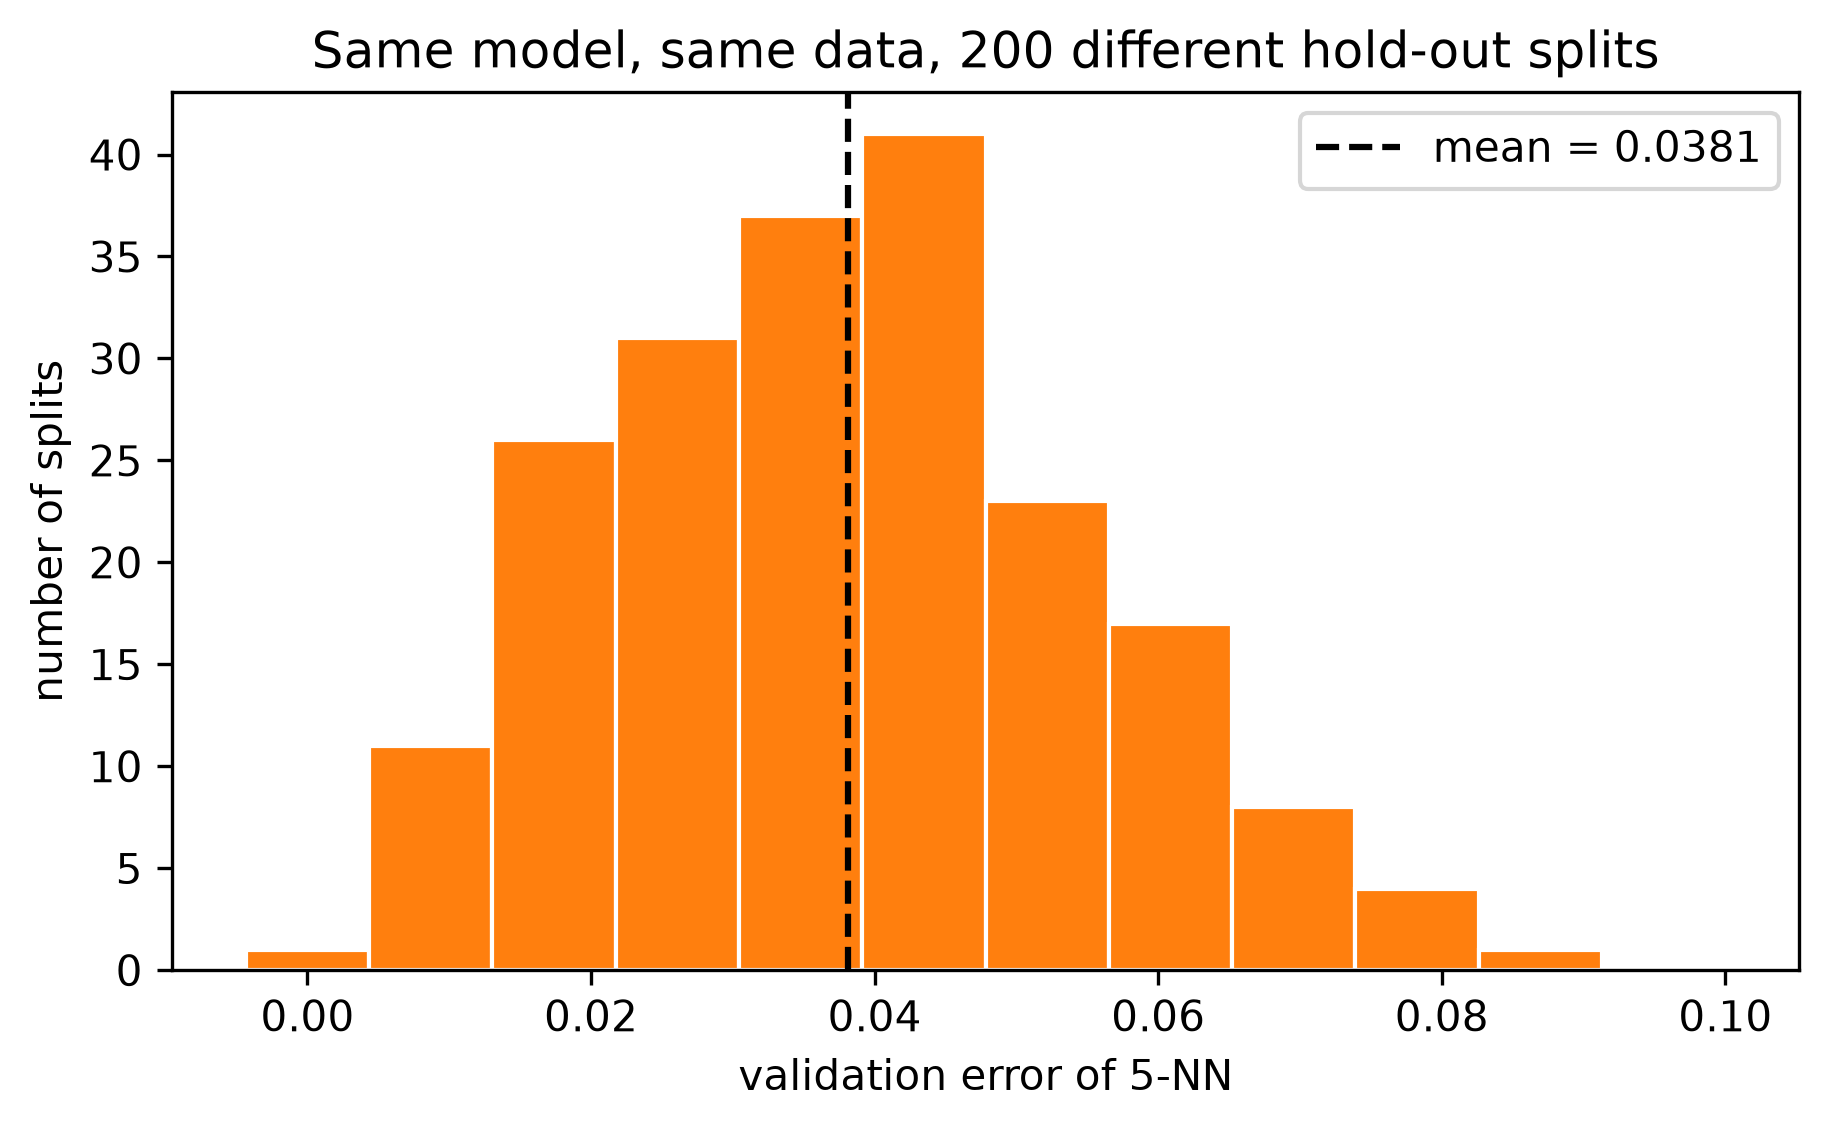

In [9]:
N_REPEATS = 200
holdout_errors = np.empty(N_REPEATS)
for s in range(N_REPEATS):
    tr, va = stratified_holdout_split(y_dev, 0.25, seed=s)            # a fresh train / validation split
    model = make_knn(5).fit(X_dev[tr], y_dev[tr])
    holdout_errors[s] = error_rate(y_dev[va], model.predict(X_dev[va]))

print(f"validation error of 5-NN over {N_REPEATS} different hold-out splits:")
print(f"  mean = {holdout_errors.mean():.4f}   std = {holdout_errors.std():.4f}"
      f"   min = {holdout_errors.min():.4f}   max = {holdout_errors.max():.4f}")
print(f"  one validation mistake changes the error by 1/{len(va)} = {1 / len(va):.4f}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(holdout_errors, bins=np.arange(-0.5, 12.5) / len(va), color="tab:orange", edgecolor="white")
ax.axvline(holdout_errors.mean(), color="black", ls="--", label=f"mean = {holdout_errors.mean():.4f}")
ax.set_xlabel("validation error of 5-NN")
ax.set_ylabel("number of splits")
ax.set_title("Same model, same data, 200 different hold-out splits")
ax.legend()
plt.show()

**Line by line**

- Each pass through the loop is one complete hold-out validation: split, fit on the training part, score on the
  validation part. Only the seed changes.
- `np.empty(N_REPEATS)` : a container for 200 numbers, filled inside the loop (Practical 3).
- `bins=np.arange(-0.5, 12.5) / len(va)` : a validation set of 115 rows can only produce error rates that are
  multiples of $1/115$ (0 mistakes, 1 mistake, 2 mistakes, ...). These bin edges put exactly one such value in the
  middle of each bar, so each bar counts the splits with 0, 1, 2, ... validation mistakes.

**Reading the plot.** The model and the data never changed, yet the validation error ranges from **0** (a perfect
score, 0 mistakes) to **0.087** (10 mistakes), a factor of "infinity" between the luckiest and the unluckiest split.
A standard deviation of 0.017 on a mean of 0.038 means that a single hold-out estimate is only good to roughly
$\pm 45\%$.

This is a serious problem for model selection. Suppose two models differ in true error by 0.01. With a single
hold-out split the noise (0.017) is larger than the difference, so which model "wins" is decided largely by which
rows happened to land in the validation set. Part 3 fixes this.

### 2c. The size of the validation set is a trade-off

Why not simply use a bigger validation set to reduce the noise? Because every row given to validation is a row taken
away from training. Let us vary the validation fraction and repeat the experiment of 2b for each value.

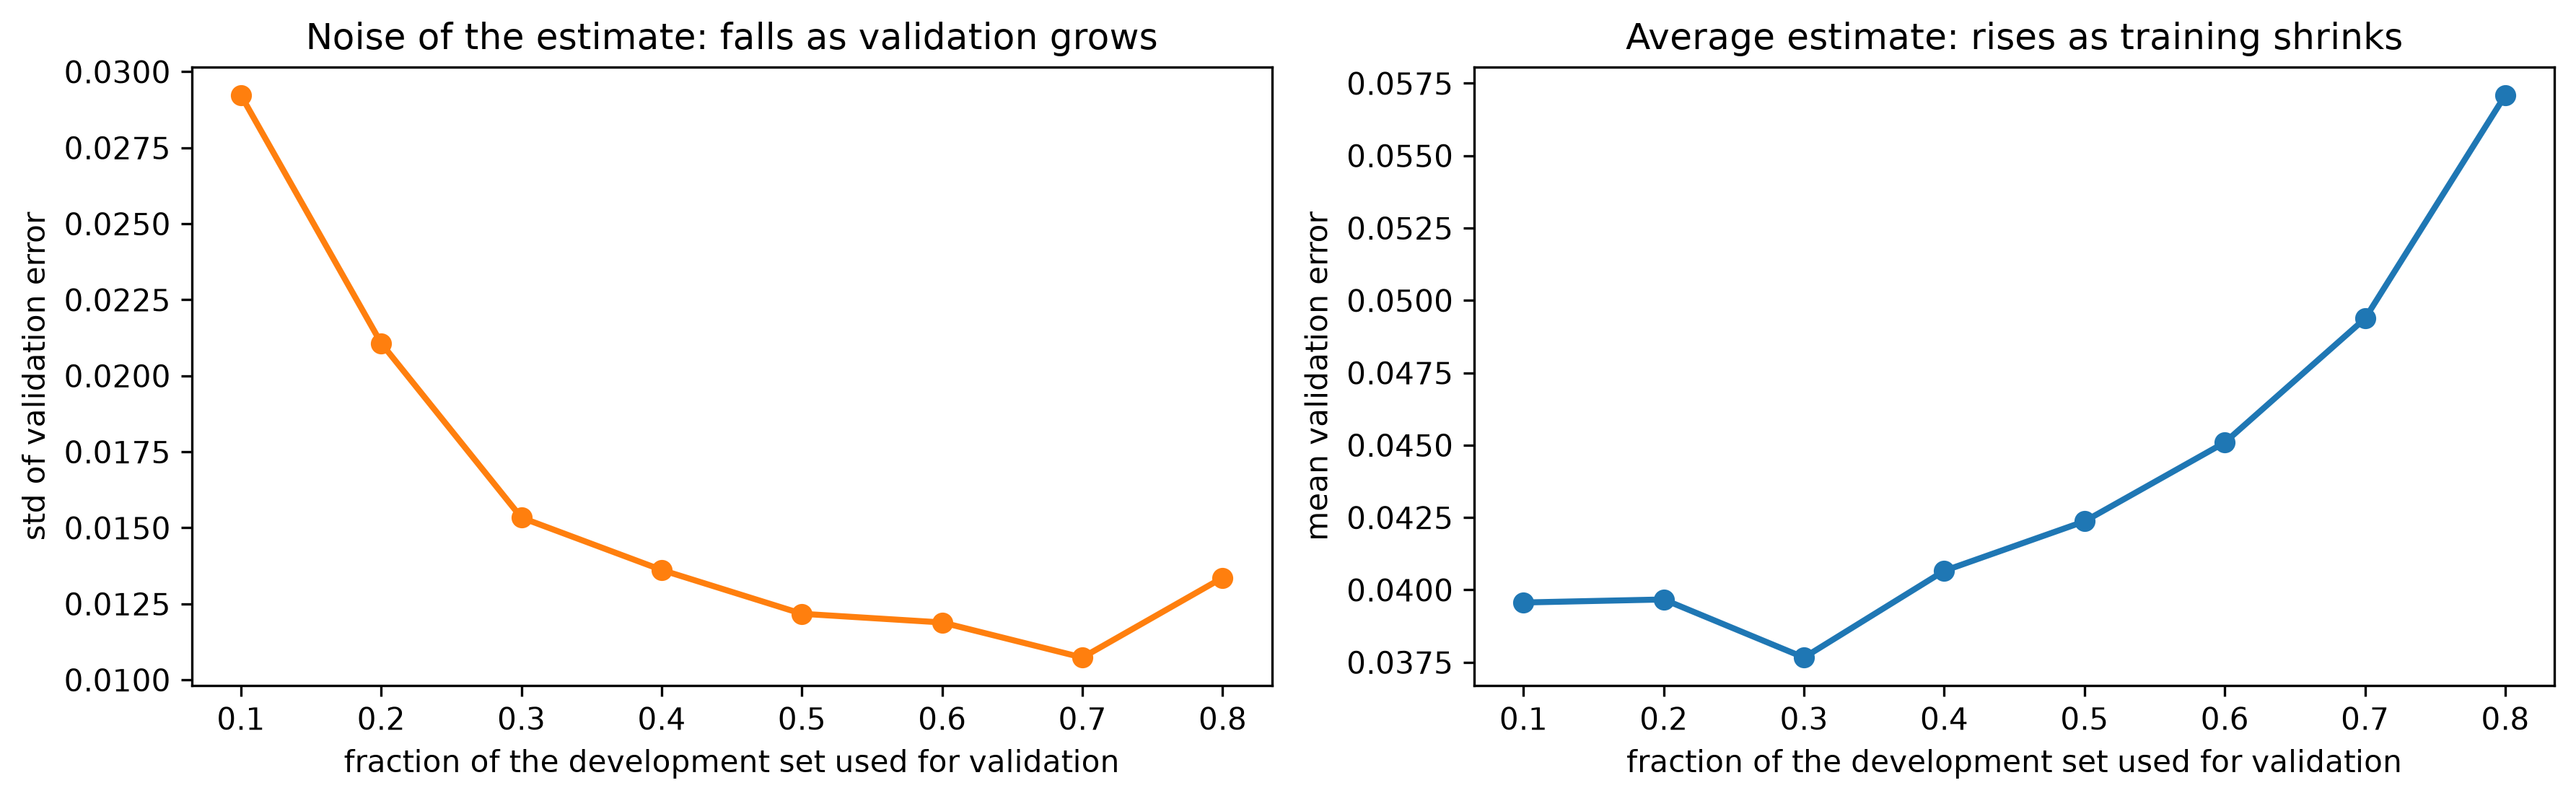

,training rows,validation rows,mean val. error,std of val. error
validation fraction,,,,
0.1,408,46,0.0396,0.0292
0.2,363,91,0.0397,0.0211
0.3,317,137,0.0377,0.0153
0.4,272,182,0.0407,0.0136
0.5,226,228,0.0424,0.0122
0.6,181,273,0.0451,0.0119
0.7,135,319,0.0494,0.0107
0.8,90,364,0.0571,0.0134


In [10]:
val_fracs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
rows = []
for f in val_fracs:
    errs = []
    for s in range(100):                                              # 100 random splits per fraction
        tr, va = stratified_holdout_split(y_dev, f, seed=s)
        model = make_knn(5).fit(X_dev[tr], y_dev[tr])
        errs.append(error_rate(y_dev[va], model.predict(X_dev[va])))
    rows.append({"validation fraction": f, "training rows": len(tr), "validation rows": len(va),
                 "mean val. error": np.mean(errs), "std of val. error": np.std(errs)})
size_table = pd.DataFrame(rows).set_index("validation fraction")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(val_fracs, size_table["std of val. error"], "o-", color="tab:orange", lw=2)
axes[0].set_title("Noise of the estimate: falls as validation grows")
axes[0].set_ylabel("std of validation error")
axes[1].plot(val_fracs, size_table["mean val. error"], "o-", color="tab:blue", lw=2)
axes[1].set_title("Average estimate: rises as training shrinks")
axes[1].set_ylabel("mean validation error")
for ax in axes:
    ax.set_xlabel("fraction of the development set used for validation")
plt.tight_layout()
plt.show()
size_table

**Line by line**

- The outer loop runs over eight validation fractions; the inner loop repeats the split 100 times for each.
- `len(tr)` and `len(va)` after the inner loop hold the sizes of the last split, which are the same for every split
  with this fraction, so they are safe to record.

**Reading the plots.** The two panels pull in opposite directions.

- **Left:** the larger the validation set, the less the estimate wobbles, because it averages over more rows: the
  standard deviation falls from 0.029 (46 validation rows) to 0.011 (319 rows). At 0.8 it ticks back up to 0.013.
  With only 90 training rows the *model itself* now changes a lot from split to split, and that extra variation of
  the model adds to the noise of the estimate.
- **Right:** the larger the validation set, the *smaller* the training set, and a model trained on fewer rows is a
  worse model. So the average validation error creeps up, slowly at first (about 0.040 up to a fraction of 0.4) and
  then quickly, to 0.057 once only a fifth of the data is left for training. (The small dip at 0.3 is just the
  noise of averaging 100 random splits.) With a large validation fraction we get a precise estimate of the error of
  a model that is worse than the one we will actually use. This systematic overestimate is called **pessimistic
  bias**.

A single hold-out split forces us to trade one of these against the other. The typical compromise is a validation
fraction of 20% to 30%. Cross-validation, next, escapes the trade-off by letting **every** row be used for validation
and (almost all rows) for training.

---
## Part 3: k-fold cross-validation from scratch

### 3a. The idea

Instead of one split, make $K$ of them, arranged so that **every row is used for validation exactly once**:

1. Shuffle the development rows and cut them into $K$ nearly equal parts, called **folds**.
2. For $j = 1, \dots, K$: train the model on all folds **except** fold $j$, and compute its error $\text{Err}_j$ on
   fold $j$.
3. Report the average: $\text{CV}_K = \frac{1}{K}\sum_{j=1}^{K} \text{Err}_j$.

With $K = 5$ every model is trained on 80% of the development rows (so the pessimistic bias of 2c is small), and
the validation error is averaged over **all** development rows (so the noise of 2b is much smaller). The price is
computing time: $K$ fits instead of one.

The picture below shows the folds for a toy dataset of 20 rows and $K = 5$, first without shuffling and then with it.

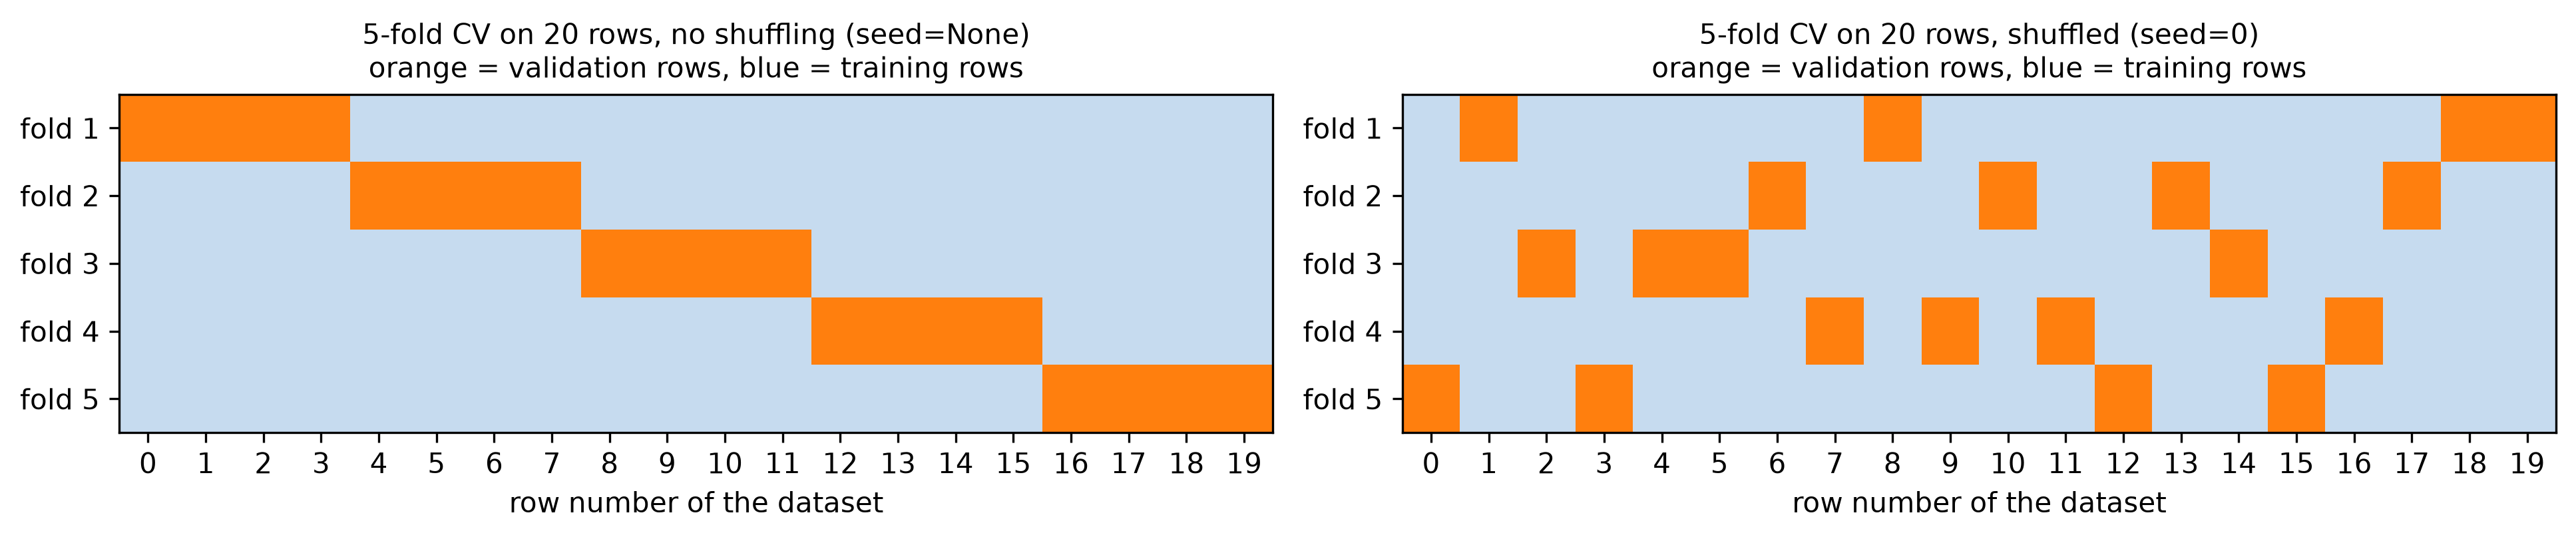

fold sizes for n = 23, K = 5 : [5, 5, 5, 4, 4]


In [11]:
def kfold_indices(n, n_folds, seed=None):
    '''K-fold cross-validation: split the row numbers 0..n-1 into n_folds (train_idx, val_idx) pairs.

    Every row appears in exactly one validation fold.
    seed=None keeps the original order; an integer shuffles the rows first (with that seed).
    '''
    indices = np.arange(n)                                  # 0, 1, ..., n-1
    if seed is not None:
        np.random.RandomState(seed).shuffle(indices)        # shuffle IN PLACE (same generator as sklearn)

    fold_sizes = np.full(n_folds, n // n_folds)            # every fold gets n // n_folds rows ...
    fold_sizes[: n % n_folds] += 1                          # ... and the first (n % n_folds) folds get one extra

    folds = []
    start = 0
    for size in fold_sizes:
        val_idx = np.sort(indices[start:start + size])      # the next block of shuffled rows = one fold
        train_idx = np.setdiff1d(np.arange(n), val_idx)     # every other row (returned sorted)
        folds.append((train_idx, val_idx))
        start += size
    return folds


fig, axes = plt.subplots(1, 2, figsize=(13, 2.8))
for ax, seed, title in zip(axes, [None, 0], ["no shuffling (seed=None)", "shuffled (seed=0)"]):
    grid = np.zeros((5, 20))                                # row j of the picture = fold j
    for j, (tr, va) in enumerate(kfold_indices(20, 5, seed)):
        grid[j, va] = 1                                     # mark the validation rows of fold j
    ax.imshow(grid, cmap=ListedColormap(["#c6dbef", "tab:orange"]), aspect="auto")
    ax.set_yticks(range(5))
    ax.set_yticklabels([f"fold {j + 1}" for j in range(5)])
    ax.set_xticks(range(20))
    ax.set_xlabel("row number of the dataset")
    ax.set_title(f"5-fold CV on 20 rows, {title}\norange = validation rows, blue = training rows", fontsize=10)
plt.tight_layout()
plt.show()

folds_demo = kfold_indices(23, 5, seed=0)                   # 23 rows: the sizes cannot all be equal
print("fold sizes for n = 23, K = 5 :", [len(va) for _, va in folds_demo])

**Line by line**

- `np.random.RandomState(seed).shuffle(indices)` : `shuffle` rearranges the array **in place** (it changes `indices`
  itself and returns nothing), unlike `permutation`, which returns a shuffled copy. We use the same generator as
  scikit-learn so that 3b can check our folds row for row.
- `np.full(n_folds, n // n_folds)` : an array of $K$ equal sizes. `//` is integer division.
- `fold_sizes[: n % n_folds] += 1` : `n % n_folds` is the **remainder**. With 23 rows and 5 folds, $23 = 5 \times 4 + 3$,
  so every fold gets 4 rows and the first 3 folds get one more: sizes 5, 5, 5, 4, 4. The printed line confirms it.
- The loop walks through the shuffled array in blocks. `start` marks where the current block begins.
- `np.sort(...)` : sorting the validation rows does not change *which* rows are in the fold, only the order in which
  they are listed. We sort because scikit-learn returns them sorted, which makes the comparison in 3b a simple
  `array_equal`.
- `np.setdiff1d(a, b)` : "set difference", the numbers in `a` that are not in `b`. The training rows of a fold are all
  rows except its validation rows.
- The picture: `grid` is a $5 \times 20$ array of zeros; `grid[j, va] = 1` sets the validation rows of fold $j$ to 1.
  `imshow` draws an array as coloured squares; `ListedColormap([...])` says "draw 0 in light blue and 1 in orange".

**Reading the picture.** Each row of the picture is one round of training. In every round four fifths of the rows
are blue (training) and one fifth is orange (validation). Look down any column: **every row of the dataset is
orange exactly once**. Without shuffling the folds are consecutive blocks; with shuffling each fold is a random
scatter of rows, which protects us against any ordering hidden in the file.

### 3b. Checking the folds against scikit-learn's `KFold`

`KFold(n_splits, shuffle, random_state).split(X)` produces the library's folds. We compare them with ours on the
454 development rows, for several seeds and without shuffling, and we also check the three properties every
$K$-fold split must have.

In [12]:
def check_partition(folds, n):
    '''True if the validation folds cover every row exactly once and never overlap their training rows.'''
    all_val = np.concatenate([va for _, va in folds])
    each_once = np.array_equal(np.bincount(all_val, minlength=n), np.ones(n))       # every row exactly once
    disjoint = all(len(np.intersect1d(tr, va)) == 0 for tr, va in folds)          # no row in both parts
    complete = all(len(tr) + len(va) == n for tr, va in folds)                    # nothing missing
    return each_once and disjoint and complete


n_dev = len(y_dev)
for seed in [None, 0, 1, 123]:
    ours = kfold_indices(n_dev, 5, seed)
    lib = list(KFold(n_splits=5, shuffle=seed is not None, random_state=seed).split(X_dev))
    identical = all(np.array_equal(tr_o, tr_l) and np.array_equal(va_o, va_l)
                    for (tr_o, va_o), (tr_l, va_l) in zip(ours, lib))
    print(f"seed = {str(seed):>4}:  valid partition = {check_partition(ours, n_dev)},"
          f"  identical to KFold = {identical},  fold sizes = {[len(va) for _, va in ours]}")

seed = None:  valid partition = True,  identical to KFold = True,  fold sizes = [91, 91, 91, 91, 90]
seed =    0:  valid partition = True,  identical to KFold = True,  fold sizes = [91, 91, 91, 91, 90]
seed =    1:  valid partition = True,  identical to KFold = True,  fold sizes = [91, 91, 91, 91, 90]
seed =  123:  valid partition = True,  identical to KFold = True,  fold sizes = [91, 91, 91, 91, 90]


**Line by line**

- `check_partition` bundles three checks:
  - `np.bincount(all_val, minlength=n)` counts how many times each row number $0 \dots n-1$ appears among all the
    validation folds; it must be exactly 1 for every row.
  - no fold shares a row between its training and validation parts,
  - training plus validation is always the whole dataset.
- `shuffle=seed is not None` : `seed is not None` is a boolean, `False` for the unshuffled case and `True` otherwise, so
  one line handles both cases. `KFold` refuses a `random_state` when `shuffle=False`, and `None` is what it expects.
- `list(...split(X_dev))` : `split` is a **generator** that produces the folds one at a time; `list(...)` collects
  all five so they can be compared.
- `zip(ours, lib)` pairs fold 1 with fold 1, fold 2 with fold 2, and so on.

**Reading the output.** Four times `True, True`. Our folds are **identical** to `KFold`'s, row for row, with and
without shuffling. With 454 rows and 5 folds the sizes are 91, 91, 91, 91, 90: $454 = 5 \times 90 + 4$, so the
first 4 folds get one extra row, exactly the rule of 3a.

### 3c. The cross-validation loop, checked against `cross_validate`

Now the loop itself: for every fold, take a **fresh** copy of the model, fit it on the training rows, and record the
error on the training rows and on the validation rows. We return both, because Part 5 needs both curves.

In [ ]:
def cross_val_errors(model, X, y, folds, error_fn=error_rate):
    '''Run cross-validation by hand.

    model    : an untrained scikit-learn model (it is copied, never modified)
    folds    : list of (train_idx, val_idx) pairs, e.g. from kfold_indices
    error_fn : error_rate for classification, mse for regression
    returns  : (train_errors, val_errors), two arrays with one entry per fold
    '''
    train_errors = np.empty(len(folds))
    val_errors = np.empty(len(folds))
    for j, (tr, va) in enumerate(folds):
        fitted = clone(model).fit(X[tr], y[tr])                       # a brand-new model, trained on K-1 folds
        train_errors[j] = error_fn(y[tr], fitted.predict(X[tr]))      # error on the rows it was trained on
        val_errors[j] = error_fn(y[va], fitted.predict(X[va]))        # error on the fold it never saw
    return train_errors, val_errors


folds_5 = kfold_indices(n_dev, 5, seed=0)
tr_err, val_err = cross_val_errors(make_knn(5), X_dev, y_dev, folds_5)

# the library check
lib = cross_validate(make_knn(5), X_dev, y_dev, cv=KFold(5, shuffle=True, random_state=0),
                     scoring="accuracy", return_train_score=True)

check = pd.DataFrame({"our training error": tr_err,
                      "sklearn training error": 1 - lib["train_score"],
                      "our validation error": val_err,
                      "sklearn validation error": 1 - lib["test_score"]},
                     index=[f"fold {j + 1}" for j in range(5)])
print("identical to cross_validate:", np.allclose(tr_err, 1 - lib["train_score"])
      and np.allclose(val_err, 1 - lib["test_score"]))
print(f"5-fold CV estimate of the error of 5-NN:  CV_5 = {val_err.mean():.4f}")
check

identical to cross_validate: True
5-fold CV estimate of the error of 5-NN:  CV_5 = 0.0375


,our training error,sklearn training error,our validation error,sklearn validation error
fold 1,0.0303,0.0303,0.0330,0.0330
fold 2,0.0331,0.0331,0.0220,0.0220
fold 3,0.0358,0.0358,0.0000,0.0000
fold 4,0.0275,0.0275,0.0769,0.0769
fold 5,0.0275,0.0275,0.0556,0.0556


**Line by line**

- `clone(model)` : returns a **fresh, untrained copy** of the model with the same settings. Why not simply call
  `model.fit` five times? Because then all five folds would share one object, and after the loop `model` would be
  left trained on the last fold only, which is an easy source of confusion (and with some models, of bugs). A clone per
  fold guarantees that the five fits are completely independent.
- `clone(model).fit(X[tr], y[tr])` : trains on the $K - 1$ training folds. Because the model is a pipeline, the
  `StandardScaler` inside it computes its means and standard deviations **from these rows only**. The validation fold
  never influences the scaling of its own evaluation.
- `error_fn=error_rate` : a function passed as an argument, with a default. For regression we will pass `mse` instead,
  and nothing else in the loop has to change.
- `cross_validate(model, X, y, cv=..., scoring="accuracy", return_train_score=True)` : the library's loop. It
  reports **accuracy** (fraction correct), so `1 - accuracy` converts it into our error rate.
- `np.allclose(a, b)` : `True` when two arrays are equal up to tiny floating-point rounding.

**Reading the output.** The four columns agree fold by fold: our loop is what `cross_validate` does. The five
validation errors differ from one fold to another (from 0 for fold 3 to 0.077 for fold 4, i.e. from 0 to 7 mistakes
out of about 91 rows), which is the hold-out noise of 2b showing up again inside each fold. The training errors, by
contrast, hardly move (0.028 to 0.036), because each training part shares most of its rows with the others. Their average, $\text{CV}_5$, is the single number we report and use.

### 3d. Cross-validation is much less noisy than a single hold-out

In 2b the same 5-NN model gave a hold-out validation error anywhere between 0 and 0.087 depending on the split.
Let us now repeat **5-fold cross-validation** 200 times with 200 different shuffles, and compare the spread of
the 200 CV estimates with the spread of the 200 hold-out estimates.

hold-out (25% validation): mean = 0.0381   std = 0.0171
5-fold cross-validation  : mean = 0.0387   std = 0.0035
the spread shrank by a factor of 4.9


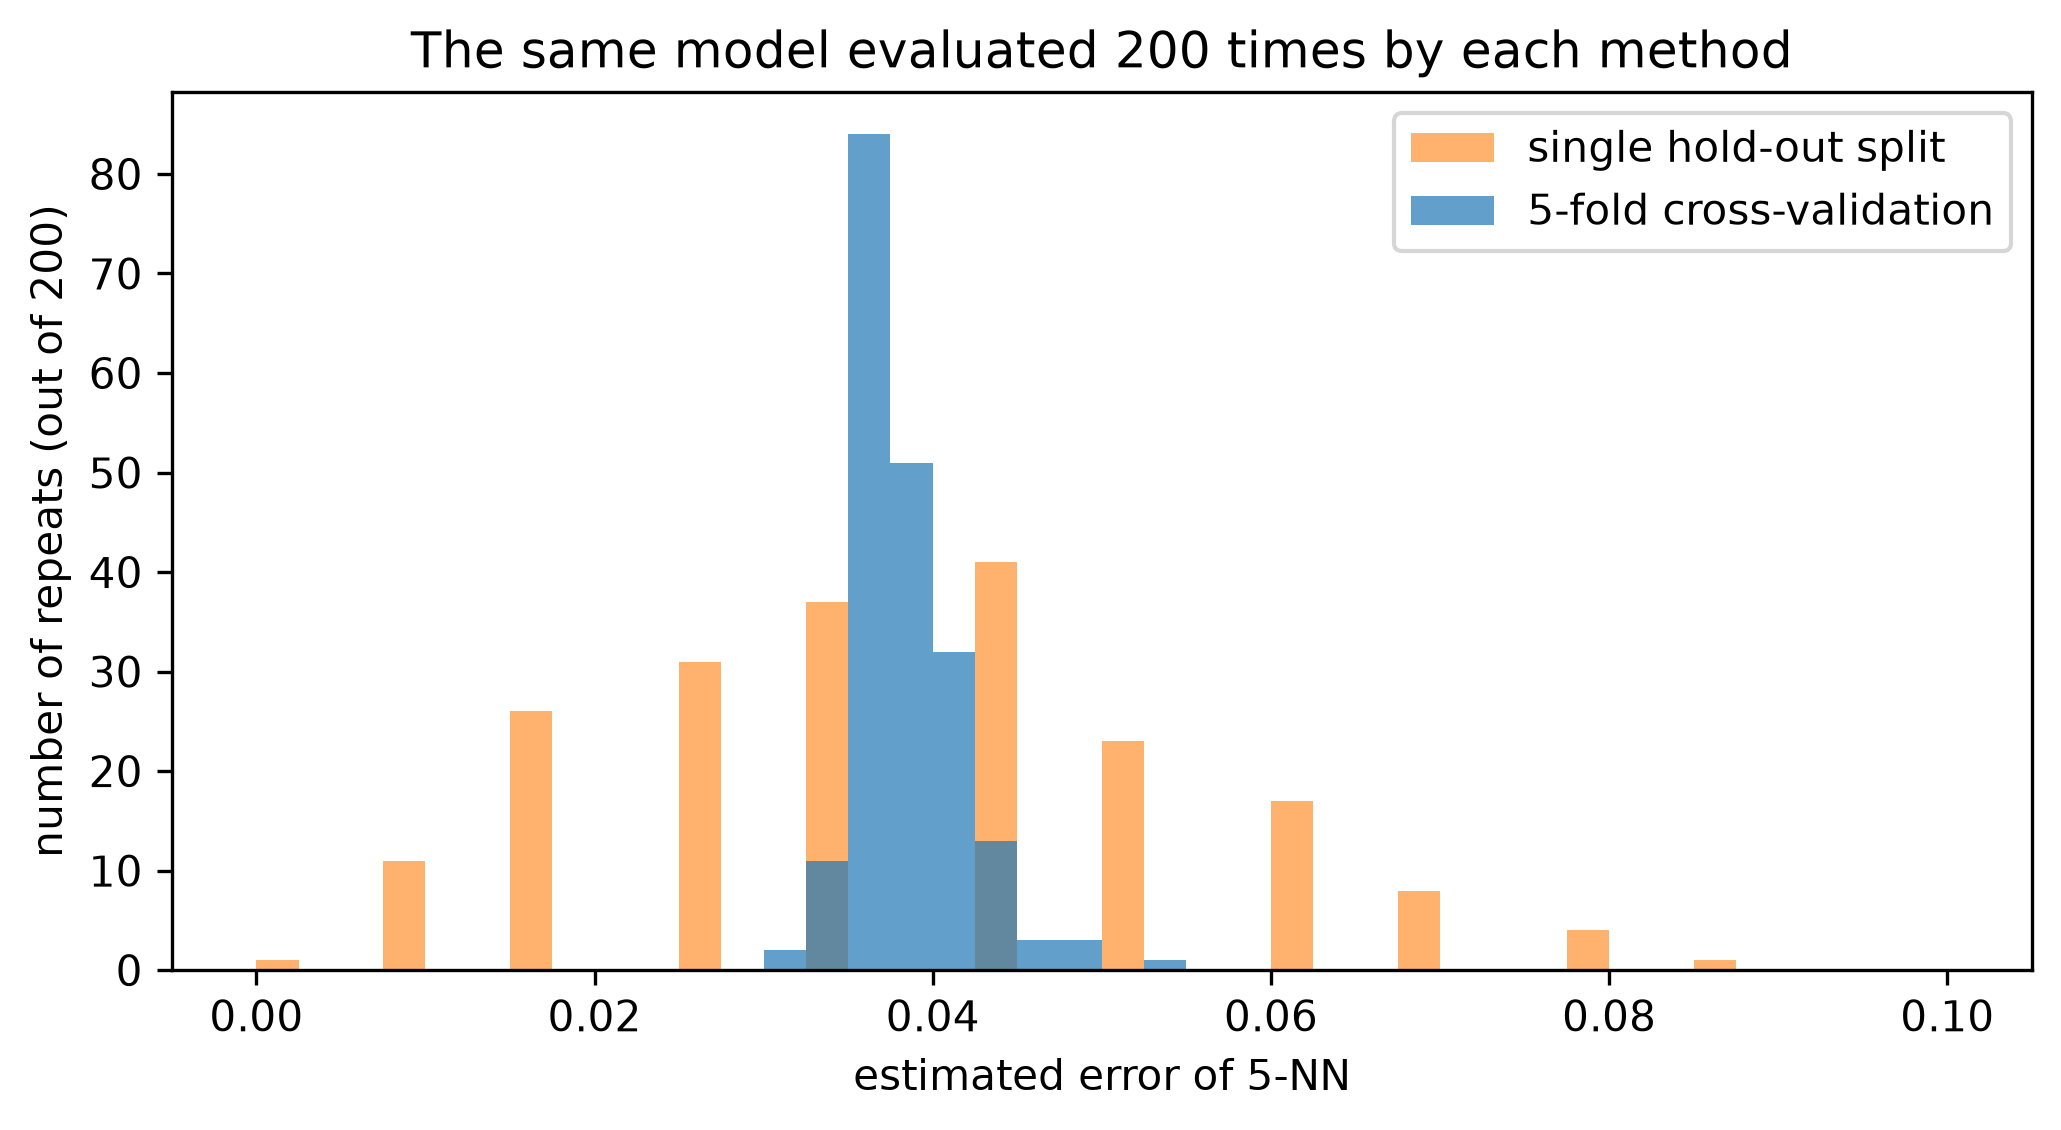

In [14]:
cv_estimates = np.empty(N_REPEATS)
for s in range(N_REPEATS):
    _, v = cross_val_errors(make_knn(5), X_dev, y_dev, kfold_indices(n_dev, 5, seed=s))
    cv_estimates[s] = v.mean()                                        # one CV_5 estimate per shuffle

print(f"hold-out (25% validation): mean = {holdout_errors.mean():.4f}   std = {holdout_errors.std():.4f}")
print(f"5-fold cross-validation  : mean = {cv_estimates.mean():.4f}   std = {cv_estimates.std():.4f}")
print(f"the spread shrank by a factor of {holdout_errors.std() / cv_estimates.std():.1f}")

fig, ax = plt.subplots(figsize=(8, 3.8))
bins = np.linspace(0, 0.1, 41)
ax.hist(holdout_errors, bins=bins, color="tab:orange", alpha=0.6, label="single hold-out split")
ax.hist(cv_estimates, bins=bins, color="tab:blue", alpha=0.7, label="5-fold cross-validation")
ax.set_xlabel("estimated error of 5-NN")
ax.set_ylabel("number of repeats (out of 200)")
ax.set_title("The same model evaluated 200 times by each method")
ax.legend()
plt.show()

**Line by line**

- For each seed we make a new set of folds, run the whole cross-validation, and keep only the average of the five
  validation errors. `_` receives the training errors, which we do not need here.
- `alpha=0.6` makes the two histograms semi-transparent so the overlap is visible.

**Reading the plot.** Both methods are centred at almost the same value (0.038 and 0.039), so on average they
estimate the same thing. But the blue histogram is about **five times narrower** (standard deviation 0.0035 instead
of 0.017). The orange bars have gaps between them because a single validation set of 115 rows can only produce
multiples of $1/115$; the CV estimate averages five folds of different sizes, so it can take many more values. Every row now contributes to the estimate,
and the five fold errors partly cancel each other's luck. A difference of 0.01 between two models, which was lost in
the noise of a single hold-out split, is now clearly visible.

The blue spread is not zero, though. Different shuffles still give slightly different CV estimates. When a decision
depends on differences smaller than this spread, you can **repeat** the cross-validation with several shuffles and
average (this is called *repeated k-fold CV*), as we will do for the learning curves in Part 6.

**How to choose $K$.** $K = 5$ and $K = 10$ are the usual choices. Larger $K$ means each model is trained on more
rows (less pessimistic bias) but costs more fits. The extreme $K = n$ is called **leave-one-out** cross-validation:
$n$ fits, each validated on a single row. You will implement it in Exercise 1.

---
## Part 4: Stratified k-fold cross-validation from scratch

### 4a. The problem: plain folds have uneven class proportions

Plain $K$-fold shuffles rows without looking at their labels. So each fold is a small random sample, and its
malignant fraction wobbles in exactly the way the plain hold-out did in 1c. The smaller the folds, the bigger the
wobble. Let us look at the malignant fraction in each of 10 plain folds.

In [15]:
overall = np.mean(y_dev == 0)                                          # malignant fraction of the dev set
plain_10 = kfold_indices(n_dev, 10, seed=0)
fracs_plain = [np.mean(y_dev[va] == 0) for _, va in plain_10]          # malignant fraction in each fold
counts_plain = [int(np.sum(y_dev[va] == 0)) for _, va in plain_10]     # malignant COUNT in each fold

print(f"malignant fraction of the development set: {overall:.4f}")
print("malignant count per plain fold   :", counts_plain)
print("malignant fraction per plain fold:", np.round(fracs_plain, 3))
print(f"smallest / largest fold fraction : {min(fracs_plain):.3f} / {max(fracs_plain):.3f}")

malignant fraction of the development set: 0.3722
malignant count per plain fold   : [22, 12, 16, 15, 16, 17, 13, 25, 16, 17]
malignant fraction per plain fold: [0.478 0.261 0.348 0.326 0.356 0.378 0.289 0.556 0.356 0.378]
smallest / largest fold fraction : 0.261 / 0.556


**Line by line**

- A list comprehension computes one malignant fraction (and one count) per validation fold.
- `int(np.sum(...))` : `np.sum` of a boolean array counts the `True`s; `int` gives a plain Python number for printing.

**Reading the output.** With 10 folds of about 45 rows each, the number of malignant tumours per fold varies a lot,
from 12 to 25, and so the fraction runs from 0.261 to 0.556 around the true 0.372. Fold 8 is more than half
malignant, fold 2 only a quarter. A fold with an unusually low malignant fraction is an easier exam than the others, and
its validation error is lower for reasons that have nothing to do with the model. With a rare class and small folds
the problem gets much worse: a fold can end up with **no** rows of the rare class at all (you will see this happen
in Exercise 2).

### 4b. The algorithm: decide *how many*, then decide *which*

A stratified split makes every fold a miniature copy of the whole dataset. We build it in two steps.

**Step 1: how many rows of each class go into each fold.** Sort the labels and deal them out to the folds like
playing cards, one at a time, round and round: the first label to fold 1, the second to fold 2, ..., the $K$-th to
fold $K$, the $(K+1)$-th to fold 1 again, and so on. Because the labels are sorted, all the cards of the first class
are dealt first, then all the cards of the second class. Every fold ends up with (almost) the same number of each
class, and the fold sizes never differ by more than one.

**Step 2: which rows of each class go into which fold.** Within one class, make a list of fold numbers with the
counts from step 1 (for example `[0, 0, 0, 1, 1, 1, 2, 2]`), shuffle that list, and give the $i$-th member of the
class the $i$-th fold number.

This is exactly the algorithm that scikit-learn's `StratifiedKFold` uses, with one small detail: it processes the
classes **in the order in which they first appear in `y`**. We do the same, so that the random shuffles happen in
the same order and our folds come out identical to the library's.

First, a toy example with 20 labels (7 of class 0, 13 of class 1) and $K = 3$.

In [16]:
def stratified_kfold_indices(y, n_folds, seed=None):
    '''Stratified K-fold: every fold gets (almost) the same proportion of every class.

    y       : (n,) array of class labels
    seed    : None = no shuffling inside the classes; an integer = shuffle with that seed
    returns : list of n_folds (train_idx, val_idx) pairs
    '''
    y = np.asarray(y)
    first_seen = np.sort(np.unique(y, return_index=True)[1])   # position where each class first appears
    classes = y[first_seen]                                    # the classes, in order of first appearance
    counts = np.array([np.sum(y == c) for c in classes])       # number of rows of each class

    # step 1: HOW MANY of each class per fold -> deal the sorted class labels round-robin
    deck = np.repeat(np.arange(len(classes)), counts)          # e.g. [0,0,...,0, 1,1,...,1]
    allocation = np.array([np.bincount(deck[f::n_folds], minlength=len(classes))
                           for f in range(n_folds)])            # (n_folds, n_classes) table of counts

    # step 2: WHICH rows of each class go to which fold -> shuffle a list of fold numbers
    rs = np.random.RandomState(seed)
    fold_of = np.empty(len(y), dtype=int)                      # fold number of every row
    for j, c in enumerate(classes):
        fold_numbers = np.repeat(np.arange(n_folds), allocation[:, j])   # e.g. [0,0,0, 1,1,1, 2,2]
        if seed is not None:
            rs.shuffle(fold_numbers)
        fold_of[y == c] = fold_numbers                         # i-th member of class c -> i-th fold number

    return [(np.flatnonzero(fold_of != f), np.flatnonzero(fold_of == f)) for f in range(n_folds)]


y_toy = np.array([0] * 7 + [1] * 13)
toy_folds = stratified_kfold_indices(y_toy, 3, seed=None)
print("toy labels :", y_toy)
for f, (tr, va) in enumerate(toy_folds):
    print(f"fold {f}: validation rows {va},  class counts {np.bincount(y_toy[va], minlength=2)}")

toy labels : [0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1]
fold 0: validation rows [ 0  1  2  7  8  9 10],  class counts [3 4]
fold 1: validation rows [ 3  4 11 12 13 14 15],  class counts [2 5]
fold 2: validation rows [ 5  6 16 17 18 19],  class counts [2 4]


**Line by line**

- `np.unique(y, return_index=True)` returns two arrays: the distinct labels (sorted) and, for each, the position of its
  **first appearance** in `y`. `[1]` keeps the positions; sorting them and reading `y` at those positions lists the
  classes in order of first appearance. For `y_toy` that is simply `[0, 1]`.
- `np.repeat(np.arange(2), [7, 13])` : repeats 0 seven times and 1 thirteen times, building the sorted **deck**
  `[0,0,0,0,0,0,0,1,1,...,1]`.
- `deck[f::n_folds]` : slicing with a step. `deck[0::3]` takes cards 0, 3, 6, 9, ...; `deck[1::3]` takes cards
  1, 4, 7, ...; this *is* the round-robin deal: fold `f` receives every third card starting from card `f`.
  `np.bincount(..., minlength=2)` then counts how many cards of each class that fold received.
- `allocation` is a table with one row per fold and one column per class. For the toy example the 7 zeros are dealt
  3, 2, 2 and the 13 ones continue the deal from where it stopped: 4, 5, 4. Every fold gets 6 or 7 rows.
- `np.repeat(np.arange(n_folds), allocation[:, j])` : for class `j`, a list with as many 0s, 1s, 2s as the folds
  should receive.
- `rs.shuffle(fold_numbers)` : randomises *which* member goes where, without changing *how many*.
- `fold_of[y == c] = fold_numbers` : the rows of class `c`, in their original order, receive the shuffled fold
  numbers one by one.
- The last line turns the fold number of every row into the familiar list of `(train_idx, val_idx)` pairs.

**Reading the output.** With `seed=None` nothing is shuffled, so the members of each class fill the folds in blocks:
rows 0–2 of class 0 go to fold 0, rows 3–4 to fold 1, and so on. Every fold has 2 or 3 zeros and 4 or 5 ones, as
close to the overall 7 : 13 ratio as whole numbers allow.

### 4c. Checking against scikit-learn's `StratifiedKFold`

We compare the folds on the breast-cancer development set (with and without shuffling), and, to make sure nothing
depends on having two classes, on the three-class **Wine** dataset (another standard UCI dataset shipped with
scikit-learn). The last case relabels the wine classes so that the class appearing first in `y` is *not* the
smallest label, which tests the "order of first appearance" detail.

In [17]:
def same_folds(ours, lib):
    '''True if two lists of (train_idx, val_idx) pairs are identical, fold by fold.'''
    return all(np.array_equal(a_tr, b_tr) and np.array_equal(a_va, b_va)
               for (a_tr, a_va), (b_tr, b_va) in zip(ours, lib))


y_wine = load_wine().target                                   # 178 wines, 3 classes: 59, 71, 48 rows
tests = [("breast cancer dev set", y_dev, 5, None),
         ("breast cancer dev set", y_dev, 5, 0),
         ("breast cancer dev set", y_dev, 10, 2026),
         ("wine, 3 classes", y_wine, 4, 7),
         ("wine, relabelled 2 - y", 2 - y_wine, 4, 7)]

for name, labels, K, seed in tests:
    ours = stratified_kfold_indices(labels, K, seed)
    lib = list(StratifiedKFold(n_splits=K, shuffle=seed is not None, random_state=seed)
               .split(np.zeros(len(labels)), labels))
    print(f"{name:<24} K = {K:>2}, seed = {str(seed):>4}:  valid partition = {check_partition(ours, len(labels))},"
          f"  identical to StratifiedKFold = {same_folds(ours, lib)}")

breast cancer dev set    K =  5, seed = None:  valid partition = True,  identical to StratifiedKFold = True
breast cancer dev set    K =  5, seed =    0:  valid partition = True,  identical to StratifiedKFold = True
breast cancer dev set    K = 10, seed = 2026:  valid partition = True,  identical to StratifiedKFold = True
wine, 3 classes          K =  4, seed =    7:  valid partition = True,  identical to StratifiedKFold = True
wine, relabelled 2 - y   K =  4, seed =    7:  valid partition = True,  identical to StratifiedKFold = True


**Line by line**

- `same_folds` : the fold-by-fold comparison from 3b, wrapped in a function so it can be reused.
- `tests` : a list of test cases, each a tuple (description, labels, $K$, seed). The loop unpacks each tuple into four
  variables.
- `StratifiedKFold(...).split(np.zeros(len(labels)), labels)` : a stratified splitter needs the labels (its second
  argument) but ignores the feature values, so an array of zeros with the right number of rows is enough.
- `2 - y_wine` : turns labels 0, 1, 2 into 2, 1, 0. The file lists class 0 first, so after relabelling the class that
  appears first is **2**, the largest label.
- `f"{name:<24}"` : left-aligns the text in a field 24 characters wide, so the printed lines line up.

**Reading the output.** Every line prints `True, True`: our stratified folds are valid partitions and are identical
to scikit-learn's, for two and for three classes, with and without shuffling, and when the classes appear in an
unusual order. Remove the `first_seen` trick from the function (use `classes = np.unique(y)` instead) and the last
line would turn `False`: the folds would still be perfectly stratified, just shuffled in a different order from the
library's.

### 4d. The effect: every fold looks like the whole dataset

malignant count per stratified fold: [17, 17, 17, 17, 16, 17, 17, 17, 17, 17]


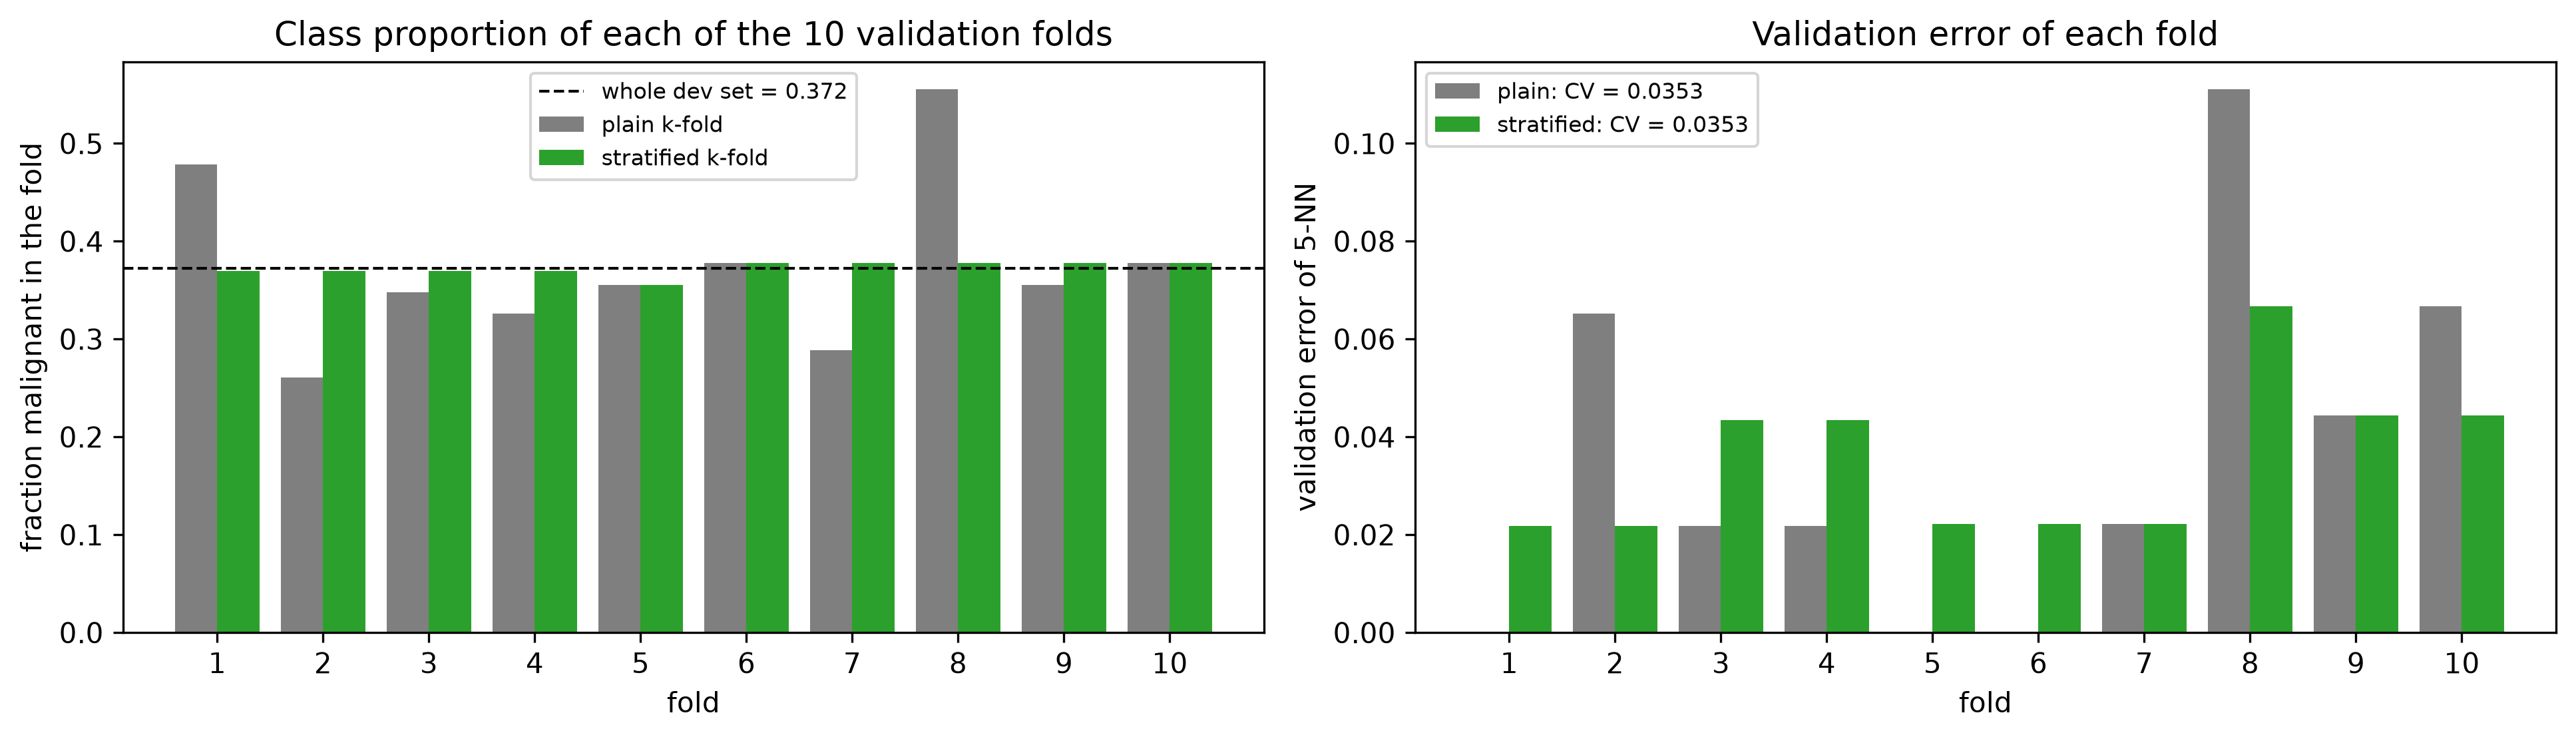

In [18]:
strat_10 = stratified_kfold_indices(y_dev, 10, seed=0)
fracs_strat = [np.mean(y_dev[va] == 0) for _, va in strat_10]
counts_strat = [int(np.sum(y_dev[va] == 0)) for _, va in strat_10]
print("malignant count per stratified fold:", counts_strat)

_, val_plain = cross_val_errors(make_knn(5), X_dev, y_dev, plain_10)
_, val_strat = cross_val_errors(make_knn(5), X_dev, y_dev, strat_10)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
pos = np.arange(1, 11)
axes[0].bar(pos - 0.2, fracs_plain, width=0.4, color="tab:grey", label="plain k-fold")
axes[0].bar(pos + 0.2, fracs_strat, width=0.4, color="tab:green", label="stratified k-fold")
axes[0].axhline(overall, color="black", ls="--", lw=1, label=f"whole dev set = {overall:.3f}")
axes[0].set_ylabel("fraction malignant in the fold")
axes[0].set_title("Class proportion of each of the 10 validation folds")
axes[1].bar(pos - 0.2, val_plain, width=0.4, color="tab:grey", label=f"plain: CV = {val_plain.mean():.4f}")
axes[1].bar(pos + 0.2, val_strat, width=0.4, color="tab:green", label=f"stratified: CV = {val_strat.mean():.4f}")
axes[1].set_ylabel("validation error of 5-NN")
axes[1].set_title("Validation error of each fold")
for ax in axes:
    ax.set_xticks(pos)
    ax.set_xlabel("fold")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Line by line**

- `strat_10` : 10 stratified folds of the development set, built by our own function.
- `cross_val_errors(...)` is run twice, on the plain and on the stratified folds, with the same 5-NN model.
- `pos - 0.2` and `pos + 0.2` with `width=0.4` : shifts the two sets of bars left and right of each fold number, so
  they stand side by side instead of on top of each other.

**Reading the plots.**

- **Left:** the grey bars (plain folds) jump up and down around the dashed line; the green bars (stratified folds)
  sit on it. Every stratified fold contains 16 or 17 malignant tumours out of 45 or 46 rows.
- **Right:** the plain fold errors range from 0 (folds 1, 5 and 6) to 0.111 (fold 8, the fold that was 56%
  malignant, i.e. the hardest exam); the stratified fold errors stay between 0.022 and 0.067. The fold errors
  still vary in both cases, because each fold is still a small sample of *rows*. Notice also that the two averages
  are the same here (CV = 0.0353 for both): stratification did not change the *estimate*, it made the individual
  folds more alike. What stratification removes is only the part of the variation caused by uneven *class
  proportions*. On a dataset with 37% of the smaller class this is a modest improvement; with a rare class (a few percent) it becomes essential,
  because plain folds can be missing the rare class entirely.

**Which to use?** For classification, stratified $K$-fold is the default choice, and it is also what scikit-learn
uses automatically when you pass `cv=5` with a classifier. For regression there are no classes, so plain (shuffled)
$K$-fold is used.

---
## Part 5: Underfitting and overfitting: error against model complexity

In Practical 3 the complexity knob was the polynomial degree, and we could measure the true test error because we
generated the data. Now we do the same experiment on **real** data, where the true error is unknown, and we let
cross-validation stand in for it. For every value of the complexity knob we compute, with the same folds:

- the **training error**, averaged over the $K$ folds (each fold's model scored on its own training rows),
- the **validation error**, averaged over the $K$ folds (each fold's model scored on its held-out fold).

### 5a. Classification: k-NN on the breast-cancer data

For k-NN the complexity knob is $k$, and it runs **backwards**: a *small* $k$ gives a flexible model whose boundary
bends around individual points, and a *large* $k$ gives a smooth, simple model (at $k$ equal to the number of training
rows it predicts the majority class everywhere). A useful way to think about it: k-NN with $n$ training rows behaves
roughly like a model with $n / k$ parameters. To make the plot read "simple on the left, complex on the right", we
draw $k$ on a reversed axis.

best k = 5:  validation error = 0.0330


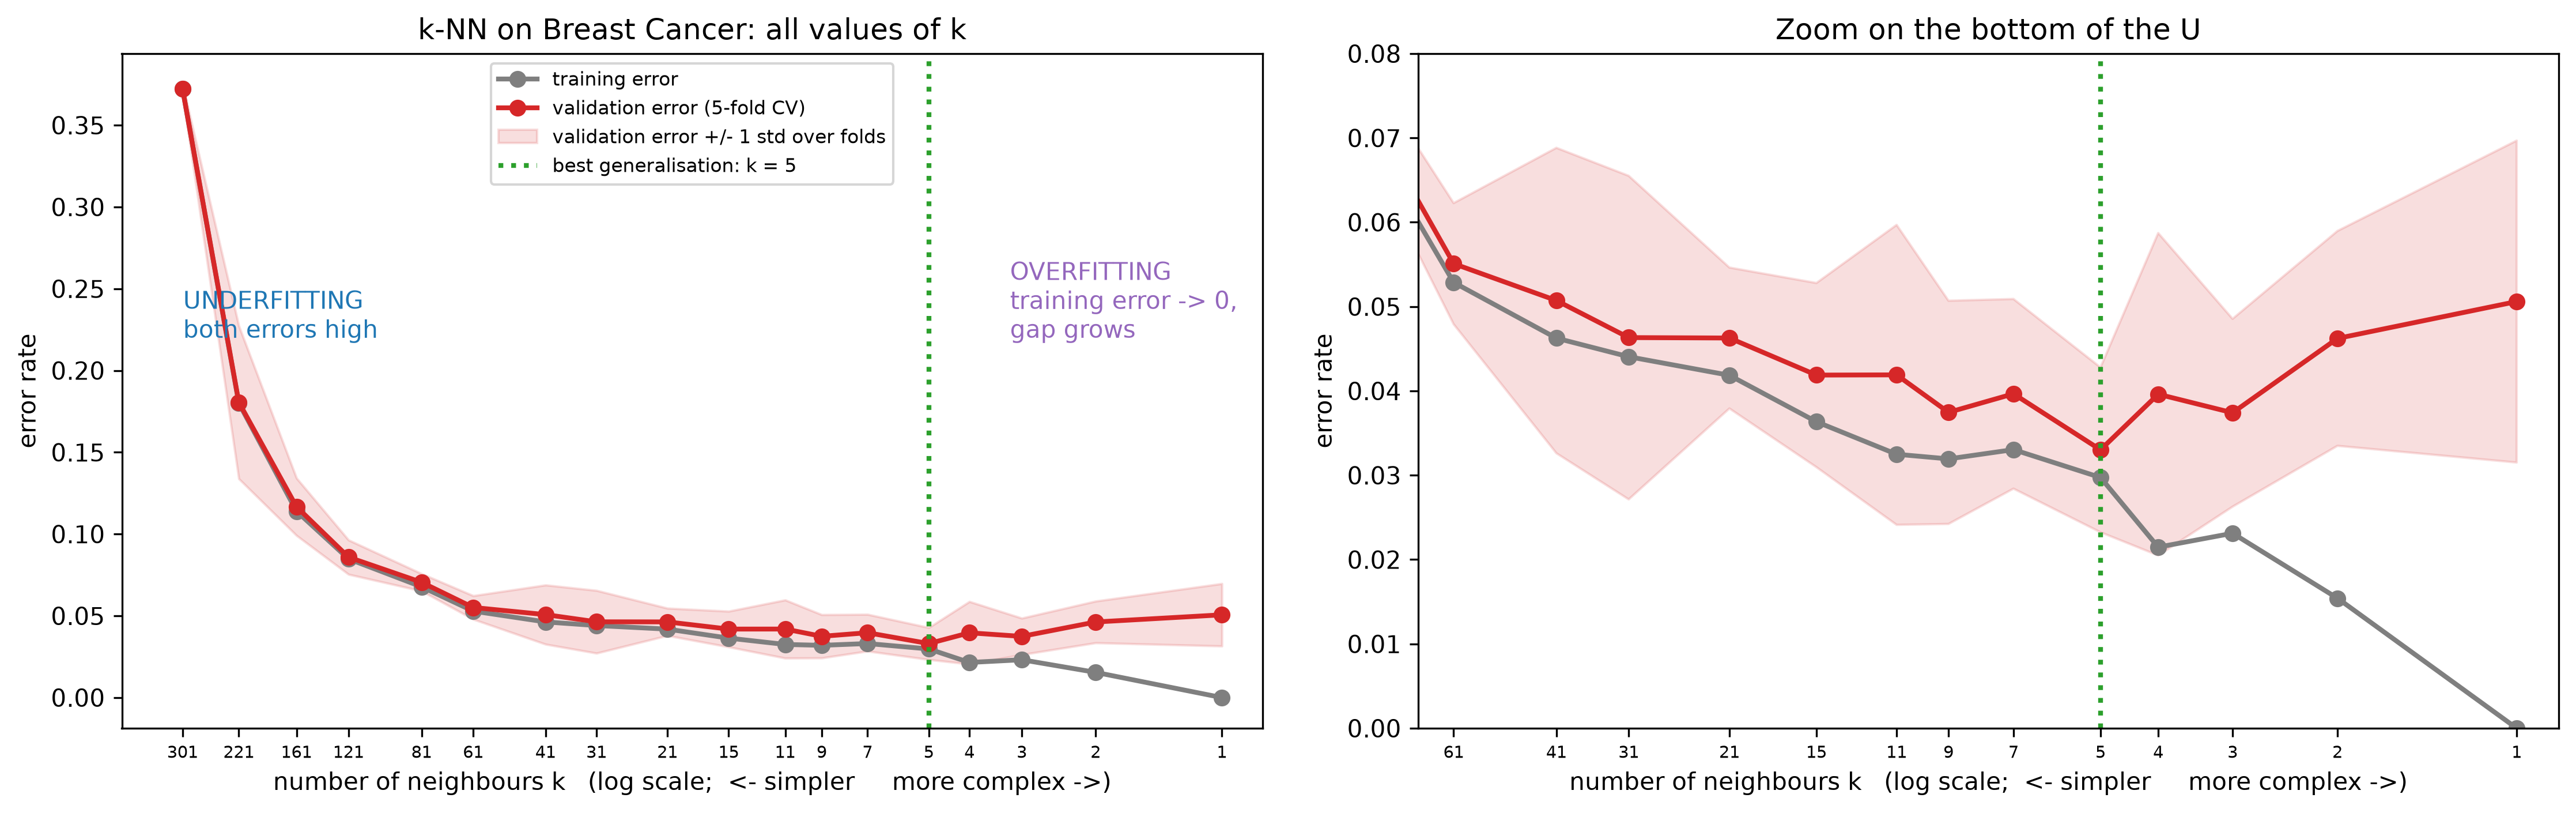

k,1,2,3,4,5,7,9,11,15,21,31,41,61,81,121,161,221,301
train mean,0.0000,0.0154,0.0231,0.0215,0.0297,0.0330,0.0319,0.0325,0.0363,0.0419,0.0441,0.0463,0.0529,0.0677,0.0848,0.1140,0.1801,0.3722
val mean,0.0506,0.0462,0.0374,0.0396,0.0330,0.0397,0.0375,0.0419,0.0419,0.0463,0.0463,0.0507,0.0551,0.0705,0.0859,0.1167,0.1806,0.3722
val std,0.0191,0.0127,0.0111,0.0191,0.0098,0.0112,0.0132,0.0178,0.0109,0.0084,0.0192,0.0181,0.0072,0.0053,0.0105,0.0175,0.0467,0.0028


In [19]:
folds_bc = stratified_kfold_indices(y_dev, 5, seed=0)        # ONE set of folds, shared by every k
k_values = [1, 2, 3, 4, 5, 7, 9, 11, 15, 21, 31, 41, 61, 81, 121, 161, 221, 301]

rows = []
for k in k_values:
    tr_e, va_e = cross_val_errors(make_knn(k), X_dev, y_dev, folds_bc)
    rows.append({"k": k, "train mean": tr_e.mean(), "val mean": va_e.mean(), "val std": va_e.std()})
knn_curve = pd.DataFrame(rows).set_index("k")

best_k = knn_curve["val mean"].idxmin()                      # the k with the smallest validation error
print(f"best k = {best_k}:  validation error = {knn_curve.loc[best_k, 'val mean']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax in axes:                                              # the same curves on both panels
    ax.plot(k_values, knn_curve["train mean"], "o-", color="tab:grey", lw=2, label="training error")
    ax.plot(k_values, knn_curve["val mean"], "o-", color="tab:red", lw=2, label="validation error (5-fold CV)")
    ax.fill_between(k_values, knn_curve["val mean"] - knn_curve["val std"],
                    knn_curve["val mean"] + knn_curve["val std"], color="tab:red", alpha=0.15,
                    label="validation error +/- 1 std over folds")
    ax.axvline(best_k, color="tab:green", ls=":", lw=2, label=f"best generalisation: k = {best_k}")
    ax.set_xscale("log")
    ax.set_xticks(k_values)
    ax.set_xticklabels(k_values, fontsize=7)
    ax.xaxis.set_minor_locator(plt.NullLocator())            # hide the extra unlabelled log-scale ticks
    ax.set_xlabel("number of neighbours k   (log scale;  <- simpler     more complex ->)")
    ax.set_ylabel("error rate")

axes[0].set_xlim(420, 0.8)                                   # limits in REVERSE order: large k on the left
axes[0].text(300, 0.22, "UNDERFITTING\nboth errors high", fontsize=10, color="tab:blue")
axes[0].text(3.2, 0.22, "OVERFITTING\ntraining error -> 0,\ngap grows", fontsize=10, color="tab:purple")
axes[0].set_title("k-NN on Breast Cancer: all values of k")
axes[0].legend(fontsize=8, loc="upper center")
axes[1].set_xlim(70, 0.85)                                   # zoom: only k <= 61 ...
axes[1].set_ylim(0, 0.08)                                    # ... and only errors below 0.08
axes[1].set_title("Zoom on the bottom of the U")
plt.tight_layout()
plt.show()

knn_curve.T

**Line by line**

- `folds_bc = stratified_kfold_indices(y_dev, 5, seed=0)` : the folds are made **once** and every value of $k$ is
  evaluated on exactly the same folds. Then differences between two values of $k$ come from the models, not from
  different random splits. (This is the same idea as sharing the 25 datasets across the panels in Practical 3, 5c.)
- `k_values` : spaced roughly evenly on a log scale, because the interesting changes happen at small $k$.
- `va_e.std()` : the standard deviation of the five fold errors, drawn as a shaded band. It shows how much the
  validation error of a single fold varies.
- `.idxmin()` : the **index label** (the value of $k$) with the smallest validation error, as in Practical 3.
- `for ax in axes:` : both panels get the same curves; afterwards each panel gets its own view.
- `ax.set_xscale("log")` : a log scale for $k$. `ax.set_xticklabels(k_values, fontsize=7)` writes the actual $k$
  values under the ticks instead of powers of ten, and `set_minor_locator(plt.NullLocator())` removes the small
  unlabelled ticks a log axis adds by default.
- `axes[0].set_xlim(420, 0.8)` : giving the limits in **reverse order** (larger number first) flips the axis, so large
  $k$ (simple models) appear on the left.
- `axes[1].set_xlim(70, 0.85)` and `set_ylim(0, 0.08)` : the right panel zooms in on the region where the validation
  error is smallest. On the left panel the point at $k = 301$ stretches the vertical axis so much that the bottom of
  the U is hard to see.
- `ax.text(x, y, "...")` : writes a label at the data coordinates `(x, y)`.
- `knn_curve.T` : the table transposed, so the 18 values of $k$ run across the page.

**Reading the plot.** This is the shape to remember from this practical.

- **The grey curve (training error) falls all the way to 0** as the model gets more complex. At $k = 1$ every training
  point is its own nearest neighbour.
- At the far left, $k = 301$, both errors are **0.372**, exactly the malignant fraction. Each training part has only
  363 rows, 228 of them benign, so a vote among 301 neighbours is always won by the benign class: the model calls
  *every* tumour benign and is wrong on every malignant one. This is underfitting in its most extreme form.
- **The red curve (validation error) is U-shaped.**
  - On the **left** (large $k$) both curves are high and close together: the model is too smooth to follow the
    boundary between the classes. That is **underfitting**, the "high bias" side of Practical 3.
  - On the **right** (small $k$) the training error keeps dropping, but the validation error turns back up and the
    **gap** between the two curves widens. The model is fitting the noise in its particular training rows. That is
    **overfitting**, the "high variance" side.
  - The **point of best generalisation** is the bottom of the red U, marked in green: $k = 5$, with a validation
    error of 0.033 (training error 0.030). At $k = 1$ the training error is 0 but the validation error is 0.051.
- The right panel zooms in on the bottom of the U. There you can see the gap between the grey and the red curve
  opening up to the right of $k = 5$. You can also see that the shaded band is wide compared with the differences
  between neighbouring values of $k$ near the bottom. Several
  values of $k$ around the minimum are statistically indistinguishable; the curve near its bottom is flat, just like
  the threshold curve in Practical 3, 2d. When that happens, a common rule of thumb is to prefer the **simplest**
  model whose validation error is within one standard error of the best (the *one-standard-error rule*, Exercise 5).

### 5b. What overfitting and underfitting look like

With 30 features we cannot draw the decision boundary. With two features we can. We take the first two columns,
*mean radius* and *mean texture*, repeat the experiment on just these two columns, and draw the regions where k-NN
predicts each class, for a very flexible, a moderate and a very smooth model. These two features separate the
classes only partly (the two clouds overlap), which is exactly what makes the difference between the three models
visible.

features: [np.str_('mean radius'), np.str_('mean texture')]


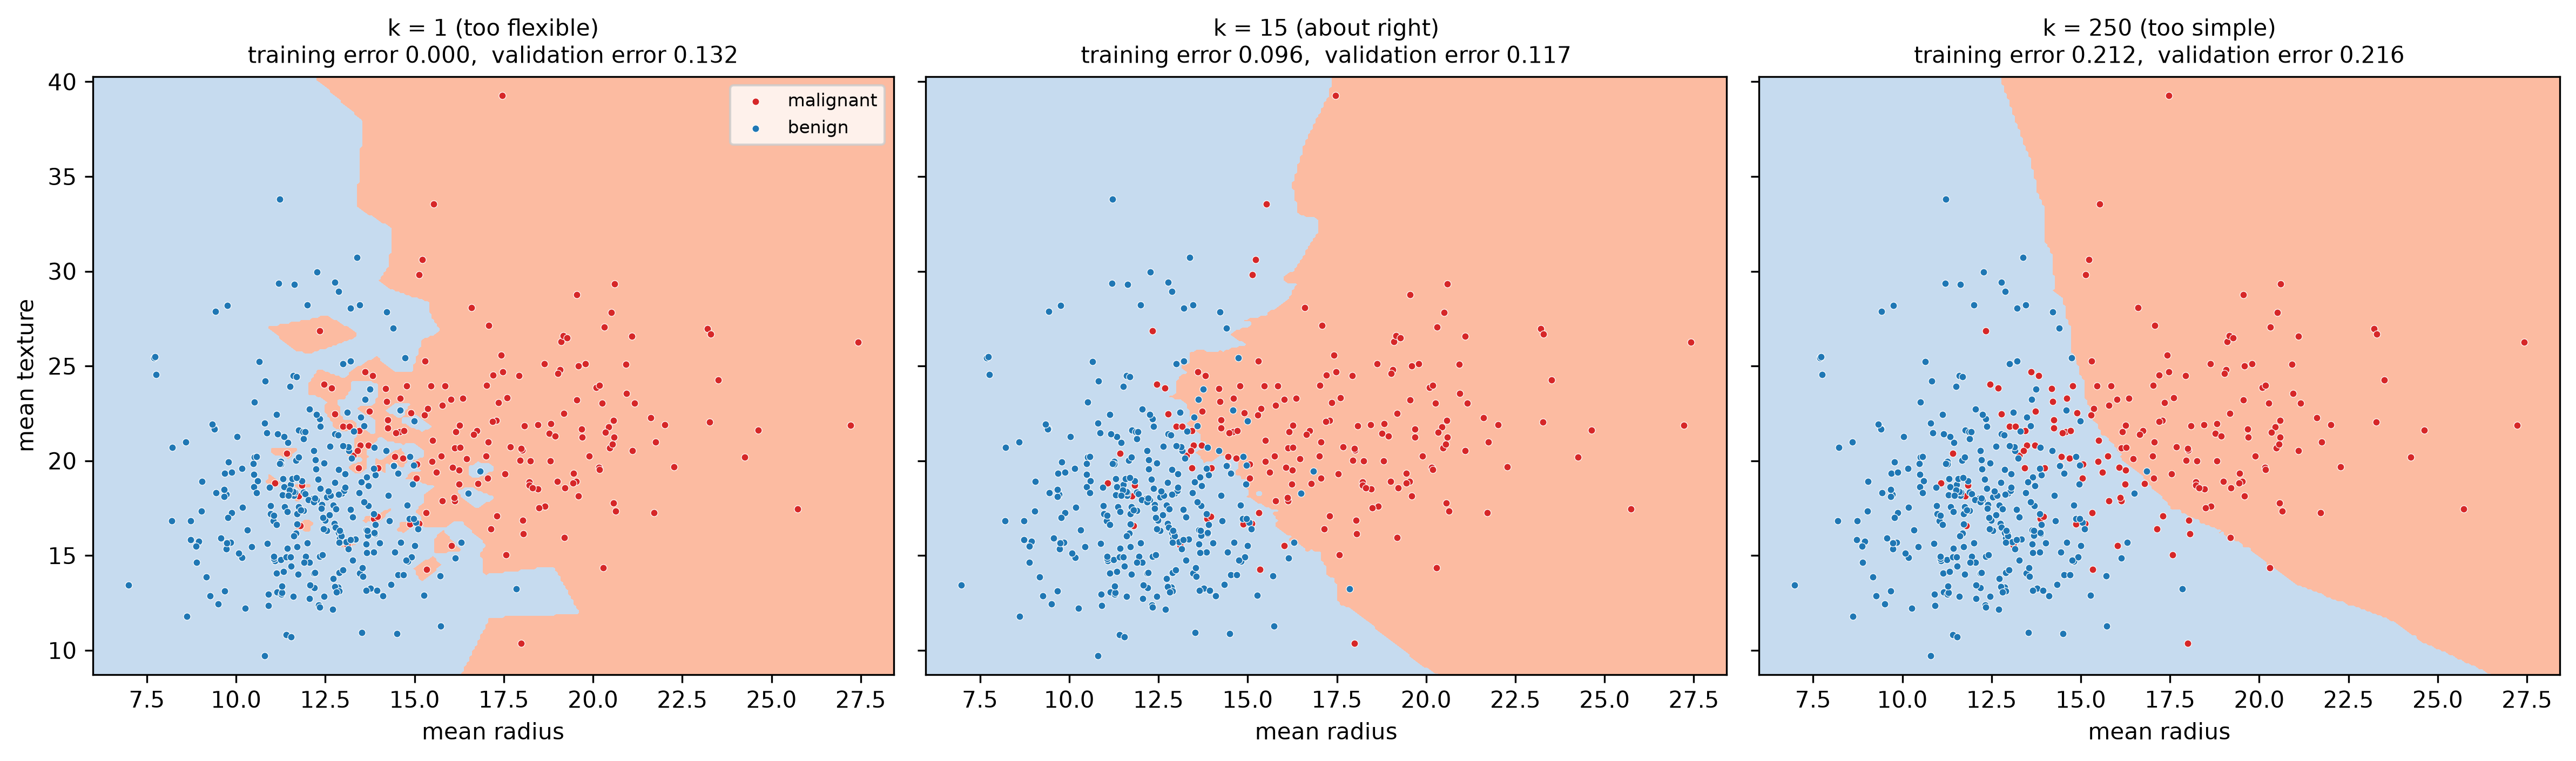

In [20]:
two = [0, 1]                                                 # column numbers of 'mean radius', 'mean texture'
X_dev_2d = X_dev[:, two]
print("features:", list(feature_names_bc[two]))

x1 = np.linspace(X_dev_2d[:, 0].min() - 1, X_dev_2d[:, 0].max() + 1, 300)
x2 = np.linspace(X_dev_2d[:, 1].min() - 1, X_dev_2d[:, 1].max() + 1, 300)
G1, G2 = np.meshgrid(x1, x2)                                 # (300, 300) grid covering the data
grid_points = np.column_stack([G1.ravel(), G2.ravel()])      # (90000, 2): every grid point as a row

region_cmap = ListedColormap(["#fcbba1", "#c6dbef"])          # light red = malignant, light blue = benign
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, k, label in zip(axes, [1, 15, 250], ["too flexible", "about right", "too simple"]):
    tr_e, va_e = cross_val_errors(make_knn(k), X_dev_2d, y_dev, folds_bc)        # errors on the same folds
    model = make_knn(k).fit(X_dev_2d, y_dev)                                     # one model on all dev rows, to draw
    regions = model.predict(grid_points).reshape(G1.shape)
    ax.contourf(G1, G2, regions, levels=[-0.5, 0.5, 1.5], cmap=region_cmap)
    for c, colour in zip([0, 1], ["tab:red", "tab:blue"]):
        ax.scatter(X_dev_2d[y_dev == c, 0], X_dev_2d[y_dev == c, 1], s=10, color=colour,
                   edgecolor="white", linewidth=0.3, label=class_names_bc[c])
    ax.set_title(f"k = {k} ({label})\ntraining error {tr_e.mean():.3f},  validation error {va_e.mean():.3f}",
                 fontsize=10)
    ax.set_xlabel("mean radius")
axes[0].set_ylabel("mean texture")
axes[0].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

**Line by line**

- `X_dev[:, two]` : all rows, only columns 0 and 1.
- The `meshgrid` / `ravel` / `reshape` recipe is the same as in Practical 3: build a fine grid of points, predict the
  class at every one of them, and fold the predictions back into a $300 \times 300$ picture.
- `ax.contourf(G1, G2, regions, levels=[-0.5, 0.5, 1.5], ...)` : fills the areas where the prediction is 0 with the
  first colour and where it is 1 with the second. The two levels bracket the values 0 and 1.
- For each $k$ we do two separate things: `cross_val_errors` gives the honest training and validation errors (on
  the same folds as 5a), while the model fitted on all development rows is used only to *draw* the regions.

**Reading the three panels.**

- **k = 1**: the boundary is jagged, and there are small islands of one colour inside the other, one for almost every
  training point that sits among points of the other class. The model draws a special region around each unusual
  point. On new data those islands are mostly wrong. Training error 0, validation error 0.132, the gap of
  overfitting.
- **k = 15**: a smooth boundary that follows the overall shape of the two clouds. Some training points are on the
  wrong side, which is fine: they are in the overlap region, where no rule can be right every time (the Bayes error of
  Practical 3). Training error 0.096, validation error 0.117: the lowest validation error of the three.
- **k = 250**: the boundary is pushed so far into the malignant cloud that many malignant tumours are called benign.
  250 of the 363 training rows vote on every prediction, so the benign majority wins far too often. The training and
  validation errors are both high (0.212 and 0.216) and almost equal: underfitting.

With only two features all errors are higher than with all 30 (compare 0.117 with the 0.033 of 5a): two measurements
simply carry less information about the diagnosis than thirty.

### 5c. Regression: decision-tree depth on the Diabetes data

The same experiment for a regression problem, with a different model family. A **decision tree** for regression
asks a sequence of yes/no questions about the features ("is `bmi` > 0.01?", then "is `s5` > −0.004?", ...). Every
path of answers ends in a **leaf**, and the prediction in a leaf is the **average target value of the training rows
that reached it**. This is the bin-averaging estimate of Practical 3, 4e, with one difference: the tree chooses the
bins itself, from the data.

The complexity knob is `max_depth`, the maximum number of questions on any path. A tree of depth $D$ has at most
$2^D$ leaves: depth 1 splits the data into 2 groups, depth 10 into as many as 1024 groups, more than the 282 or 283
rows in each training part, so most leaves end up holding only one or two patients.

For regression the error is the **MSE**, and the folds are plain (shuffled) $K$-fold, because there are no classes
to stratify on.

best depth = 2:  validation MSE = 4091.8
baseline (always predict the training mean): validation MSE = 5943.0


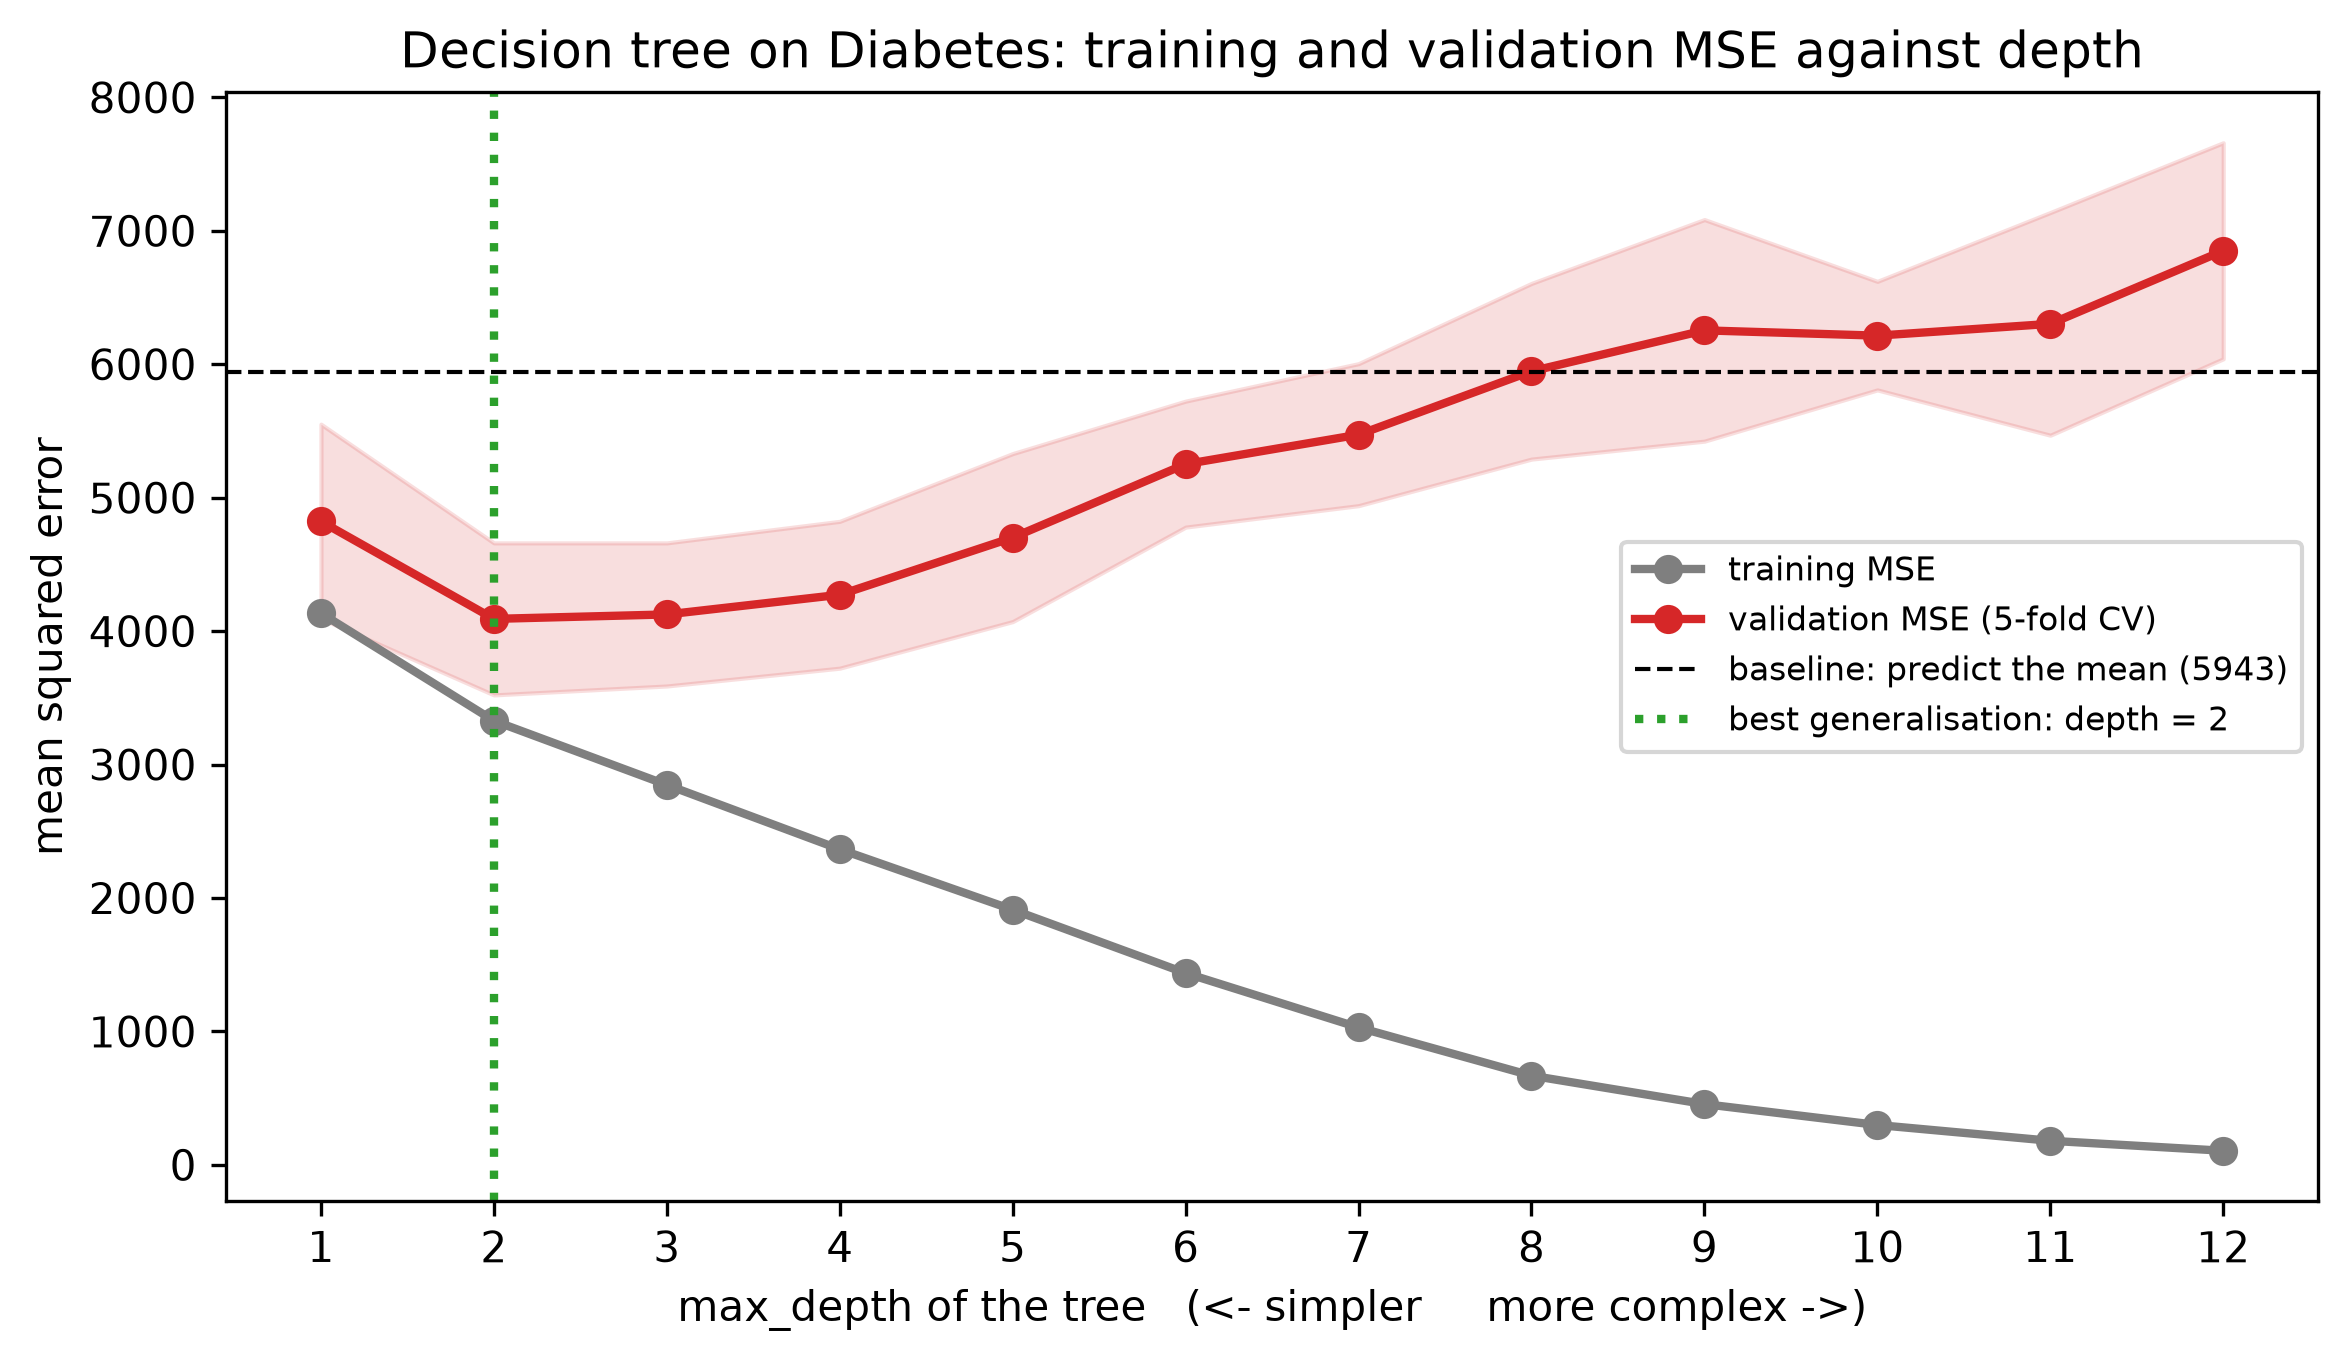

max_depth,1,2,3,4,5,6,7,8,9,10,11,12
train MSE,4134.5,3328.3,2847.8,2365.3,1912.1,1437.1,1029.7,668.6,455.5,298.9,180.6,105.8
val MSE,4822.6,4091.8,4125.1,4272.7,4701.1,5251.7,5472.5,5947.7,6254.1,6214.5,6302.8,6850.5
val std,728.5,569.7,536.3,550.2,629.5,472.1,532.1,658.3,830.3,406.8,834.5,809.7


In [21]:
folds_db = kfold_indices(len(yr_dev), 5, seed=0)            # plain 5-fold on the 353 development patients
depths = list(range(1, 13))

rows = []
for D in depths:
    tree = DecisionTreeRegressor(max_depth=D, random_state=0)
    tr_e, va_e = cross_val_errors(tree, Xr_dev, yr_dev, folds_db, error_fn=mse)
    rows.append({"max_depth": D, "train MSE": tr_e.mean(), "val MSE": va_e.mean(), "val std": va_e.std()})
tree_curve = pd.DataFrame(rows).set_index("max_depth")

best_depth = tree_curve["val MSE"].idxmin()
baseline = np.mean([mse(yr_dev[va], np.full(len(va), yr_dev[tr].mean()))    # predict the TRAINING mean
                    for tr, va in folds_db])                                  # for every validation patient
print(f"best depth = {best_depth}:  validation MSE = {tree_curve.loc[best_depth, 'val MSE']:.1f}")
print(f"baseline (always predict the training mean): validation MSE = {baseline:.1f}")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(depths, tree_curve["train MSE"], "o-", color="tab:grey", lw=2, label="training MSE")
ax.plot(depths, tree_curve["val MSE"], "o-", color="tab:red", lw=2, label="validation MSE (5-fold CV)")
ax.fill_between(depths, tree_curve["val MSE"] - tree_curve["val std"],
                tree_curve["val MSE"] + tree_curve["val std"], color="tab:red", alpha=0.15)
ax.axhline(baseline, color="black", ls="--", lw=1, label=f"baseline: predict the mean ({baseline:.0f})")
ax.axvline(best_depth, color="tab:green", ls=":", lw=2, label=f"best generalisation: depth = {best_depth}")
ax.set_xticks(depths)
ax.set_xlabel("max_depth of the tree   (<- simpler     more complex ->)")
ax.set_ylabel("mean squared error")
ax.set_title("Decision tree on Diabetes: training and validation MSE against depth")
ax.legend(fontsize=8)
plt.show()

tree_curve.T.round(1)

**Line by line**

- `kfold_indices(len(yr_dev), 5, seed=0)` : plain 5-fold from Part 3; the regression data has no classes.
- `DecisionTreeRegressor(max_depth=D, random_state=0)` : `random_state` fixes the (rare) random tie-breaking inside the
  tree-growing algorithm, so the results are reproducible.
- `error_fn=mse` : the only change needed to use `cross_val_errors` for regression.
- `baseline` : for every fold, predict the **training** fold's mean progression for every validation patient, and
  compute the MSE; then average over the folds. `np.full(len(va), value)` makes an array of `len(va)` copies of one
  value (Practical 3). This is the simplest possible "model", a constant, and any useful model must get below it.
- The rest of the plot is the same as in 5a, with an ordinary (not reversed) x-axis because deeper means more complex.

**Reading the plot.** The same story as 5a, now in regression and with a completely different model.

- The **training MSE** falls steadily towards 0 (from 4135 at depth 1 to 106 at depth 12): a deep enough tree gives
  almost every training patient their own leaf.
- The **validation MSE** falls from depth 1 (4823) to depth 2 (4092), then climbs steadily. At depth 8 it reaches
  the baseline (5948 against 5943), and deeper trees are *worse than the baseline*: the deep tree is so busy
  memorising individual patients that it predicts new patients worse than simply guessing the average.
- The best generalisation is at **depth 2** (four leaves), with depth 3 almost as good (4125, well inside the
  shaded band): the data supports only a few broad groups of patients.
  Most of the variance in disease progression is not explained by these ten features, and a flexible model cannot
  create information that is not there; it can only fit noise.

### 5d. The same idea in one dimension

To *see* the fitted regression function we again reduce to one feature: body-mass index. Each panel fits a tree of
a different depth to `bmi` alone and draws its prediction as a staircase over the data.

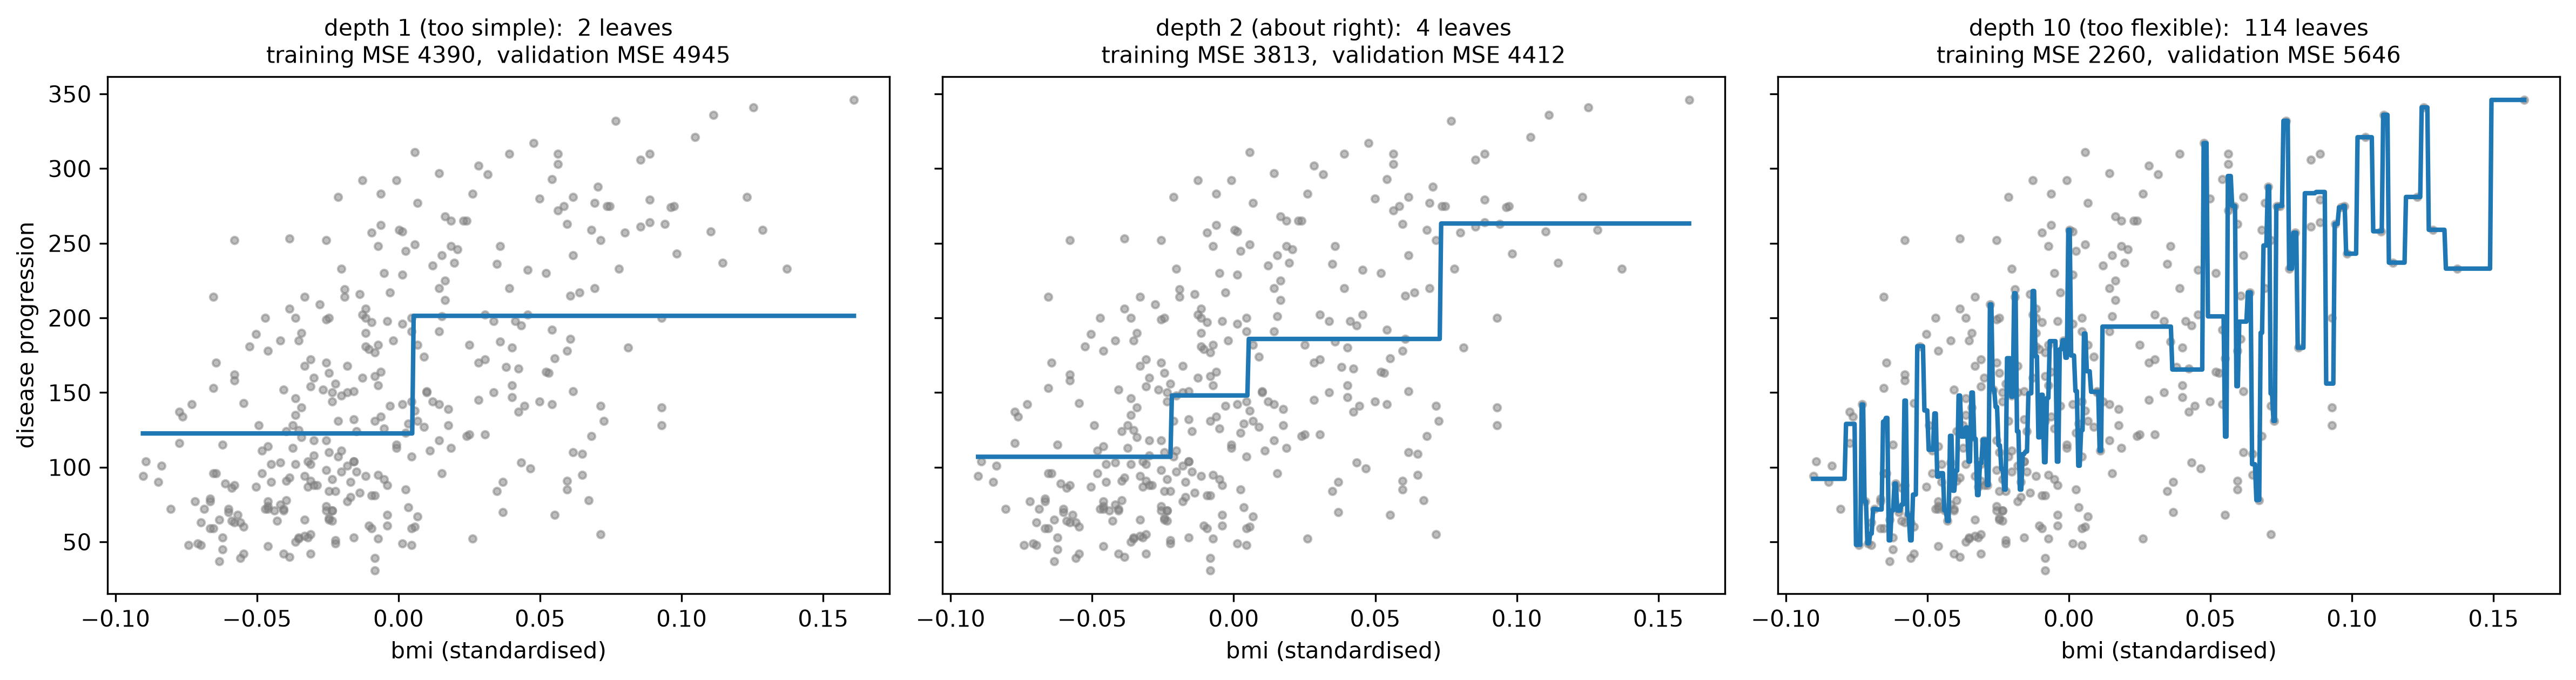

In [22]:
bmi_dev = Xr_dev[:, [2]]                                     # (353, 1): column 2 = bmi, kept 2-D for sklearn
bmi_line = np.linspace(bmi_dev.min(), bmi_dev.max(), 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
for ax, D, label in zip(axes, [1, 2, 10], ["too simple", "about right", "too flexible"]):
    tree = DecisionTreeRegressor(max_depth=D, random_state=0)
    tr_e, va_e = cross_val_errors(tree, bmi_dev, yr_dev, folds_db, error_fn=mse)
    fitted = clone(tree).fit(bmi_dev, yr_dev)                # one tree on all development rows, to draw
    ax.scatter(bmi_dev[:, 0], yr_dev, s=10, color="tab:grey", alpha=0.5)
    ax.plot(bmi_line[:, 0], fitted.predict(bmi_line), color="tab:blue", lw=2)
    ax.set_title(f"depth {D} ({label}):  {fitted.get_n_leaves()} leaves\n"
                 f"training MSE {tr_e.mean():.0f},  validation MSE {va_e.mean():.0f}", fontsize=10)
    ax.set_xlabel("bmi (standardised)")
axes[0].set_ylabel("disease progression")
plt.tight_layout()
plt.show()

**Line by line**

- `Xr_dev[:, [2]]` : the list `[2]` (rather than the number `2`) keeps the result **two-dimensional**, shape
  `(353, 1)`. scikit-learn always expects a matrix with one row per sample, even when there is only one feature.
- `.reshape(-1, 1)` : turns the 500 grid values into a `(500, 1)` matrix for the same reason; `-1` means "work out this
  size yourself".
- `fitted.get_n_leaves()` : the number of leaves, i.e. the number of flat steps in the staircase.

**Reading the three panels.** Depth 1 is one question and two steps: small bmi versus large bmi. It captures the
main trend but nothing more (underfitting: training MSE 4390, validation MSE 4945). Depth 2 has four steps and the
lowest validation MSE of the three (4412). Depth 10 has 114 tiny steps that jump up and down to follow individual
patients: in the dense middle of the data the staircase spikes towards single points. That is what "fitting the
noise" looks like. Its training MSE drops to 2260 but its validation MSE rises to 5646, far worse than depth 2.

Why does the training MSE of depth 10 not fall to 0? Several patients share *exactly* the same bmi value but have
different progressions. No rule that looks only at bmi can give them different predictions, so the best any tree
can do for them is predict their average. This is the irreducible error of Practical 3 made visible: the same input,
different outputs. Compare with the 4-bin, 12-bin and 60-bin panels of Practical 3, 4e: the same three
pictures, now on real data.

---
## Part 6: Learning curves: error against training-set size

The complexity curve of Part 5 keeps the data fixed and varies the model. A **learning curve** does the opposite:
it keeps the model fixed and varies the **number of training rows** $m$. For every $m$ we train on $m$ rows and record
the training error and the validation error.

What to expect:

- The **training error rises** with $m$. With very few rows almost any model can fit them all; the more rows there
  are, the harder it is to fit every one.
- The **validation error falls** with $m$. More data gives a better-estimated model.
- The two curves approach each other. The **level** they approach tells you about **bias** (how good this model
  family can get), and the **gap** between them tells you about **variance** (how much the model is still fitting
  the particulars of its training rows).

This makes learning curves a diagnostic tool: they tell you whether **collecting more data** would help.

### 6a. Learning curves from scratch, checked against `learning_curve`

The procedure, for each cross-validation fold: put the fold's training rows in a random order, and for each size $m$
train on the **first $m$** of them (a random subset of size $m$) and evaluate on the **whole** validation fold.
Using the first $m$ of one shuffled list means that the subsets are **nested**: the rows used at size 20 are also used
at size 40, 60, and so on, so the curves change smoothly instead of jumping between unrelated subsets.

In [ ]:
def learning_curve_errors(model, X, y, folds, train_sizes, seed, error_fn=error_rate):
    '''Learning curve by hand.

    For each fold: shuffle its training rows, then for each size m fit on the first m of them.
    returns (train_err, val_err), each of shape (len(train_sizes), len(folds))
    '''
    rs = np.random.RandomState(seed)
    train_err = np.empty((len(train_sizes), len(folds)))
    val_err = np.empty((len(train_sizes), len(folds)))
    for j, (tr, va) in enumerate(folds):
        tr = rs.permutation(tr)                                   # this fold's training rows, in random order
        for i, m in enumerate(train_sizes):
            subset = tr[:m]                                       # the first m of them
            fitted = clone(model).fit(X[subset], y[subset])
            train_err[i, j] = error_fn(y[subset], fitted.predict(X[subset]))   # error on its own m rows
            val_err[i, j] = error_fn(y[va], fitted.predict(X[va]))             # error on the WHOLE fold
    return train_err, val_err


sizes = np.array([10, 20, 30, 45, 60, 80, 100, 130, 160, 200, 250, 300, 363])   # 363 = smallest training fold
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

lc_tr, lc_va = learning_curve_errors(logreg, X_dev, y_dev, folds_bc, sizes, seed=0)

# the library check
sizes_lib, lib_tr, lib_va = learning_curve(logreg, X_dev, y_dev, train_sizes=sizes, cv=folds_bc,
                                           scoring="accuracy", shuffle=True, random_state=0)
print("same training sizes           :", np.array_equal(sizes_lib, sizes))
print("training errors identical     :", np.allclose(lc_tr, 1 - lib_tr))
print("validation errors identical   :", np.allclose(lc_va, 1 - lib_va))

pd.DataFrame({"training error": lc_tr.mean(axis=1), "validation error": lc_va.mean(axis=1)},
             index=pd.Index(sizes, name="training rows m")).T

same training sizes           : True
training errors identical     : True
validation errors identical   : True


training rows m,10,20,30,45,60,80,100,130,160,200,250,300,363
training error,0.0000,0.0000,0.0067,0.0133,0.0100,0.0100,0.012,0.0123,0.0112,0.0090,0.0104,0.012,0.011
validation error,0.1101,0.0684,0.0529,0.0419,0.0375,0.0463,0.044,0.0330,0.0330,0.0264,0.0308,0.033,0.033


**Line by line**

- `rs.permutation(tr)` : a shuffled copy of this fold's training row numbers. One generator `rs` is used for all folds
  in turn, exactly as scikit-learn does, which is what makes the library check possible.
- `tr[:m]` : the first `m` shuffled rows. Because every size takes a prefix of the **same** shuffled list, the subsets
  are nested.
- `train_err[i, j]` : row `i` is the size, column `j` the fold. So `lc_va.mean(axis=1)` averages across the folds and
  gives one validation error per size.
- `LogisticRegression(max_iter=5000)` : logistic regression from Practical 3, inside a pipeline with a scaler.
  `max_iter` raises the limit on the number of optimisation steps so that the solver always finishes.
- `learning_curve(..., cv=folds_bc, shuffle=True, random_state=0)` : the library version. Note `cv=folds_bc`: every
  scikit-learn function that takes a `cv` argument also accepts **a list of `(train_idx, val_idx)` pairs**, so we can
  hand it *our own* folds. It returns the sizes and two arrays of accuracies of shape `(sizes, folds)`.
- `pd.Index(sizes, name=...)` : gives the table's index a name, which is printed as its heading.

**Reading the output.** All three checks are `True`: our learning curve reproduces the library's number for number.
The table already shows the expected pattern: with 10 training rows logistic regression fits them perfectly
(training error 0) but gets 11% of the validation fold wrong (0.110); as $m$ grows, the validation error falls to
about 0.03 while the training error rises slightly above zero, to about 0.01. The values wobble a little (for
example 0.046 at $m = 80$ after 0.038 at $m = 60$) because each point comes from just one random subset per fold;
6b removes most of this wobble by averaging.

### 6b. Three models, three diagnoses

One learning curve is noisy, because each point comes from one random subset per fold. To see the shapes clearly we
**repeat** the whole procedure with 10 different sets of stratified folds and average (repeated $K$-fold, as
suggested in 3d). We compare three models:

- a **decision stump** (a tree of depth 1: a single yes/no question), which we expect to be too simple,
- **logistic regression**, a linear model with one weight per feature (31 parameters in all). Logistic regression
  was the reference classifier of Practical 3, and in Part 7 it will turn out to be the best model family for this
  dataset, so we expect it to be about right,
- **1-NN**, which we know is too flexible.

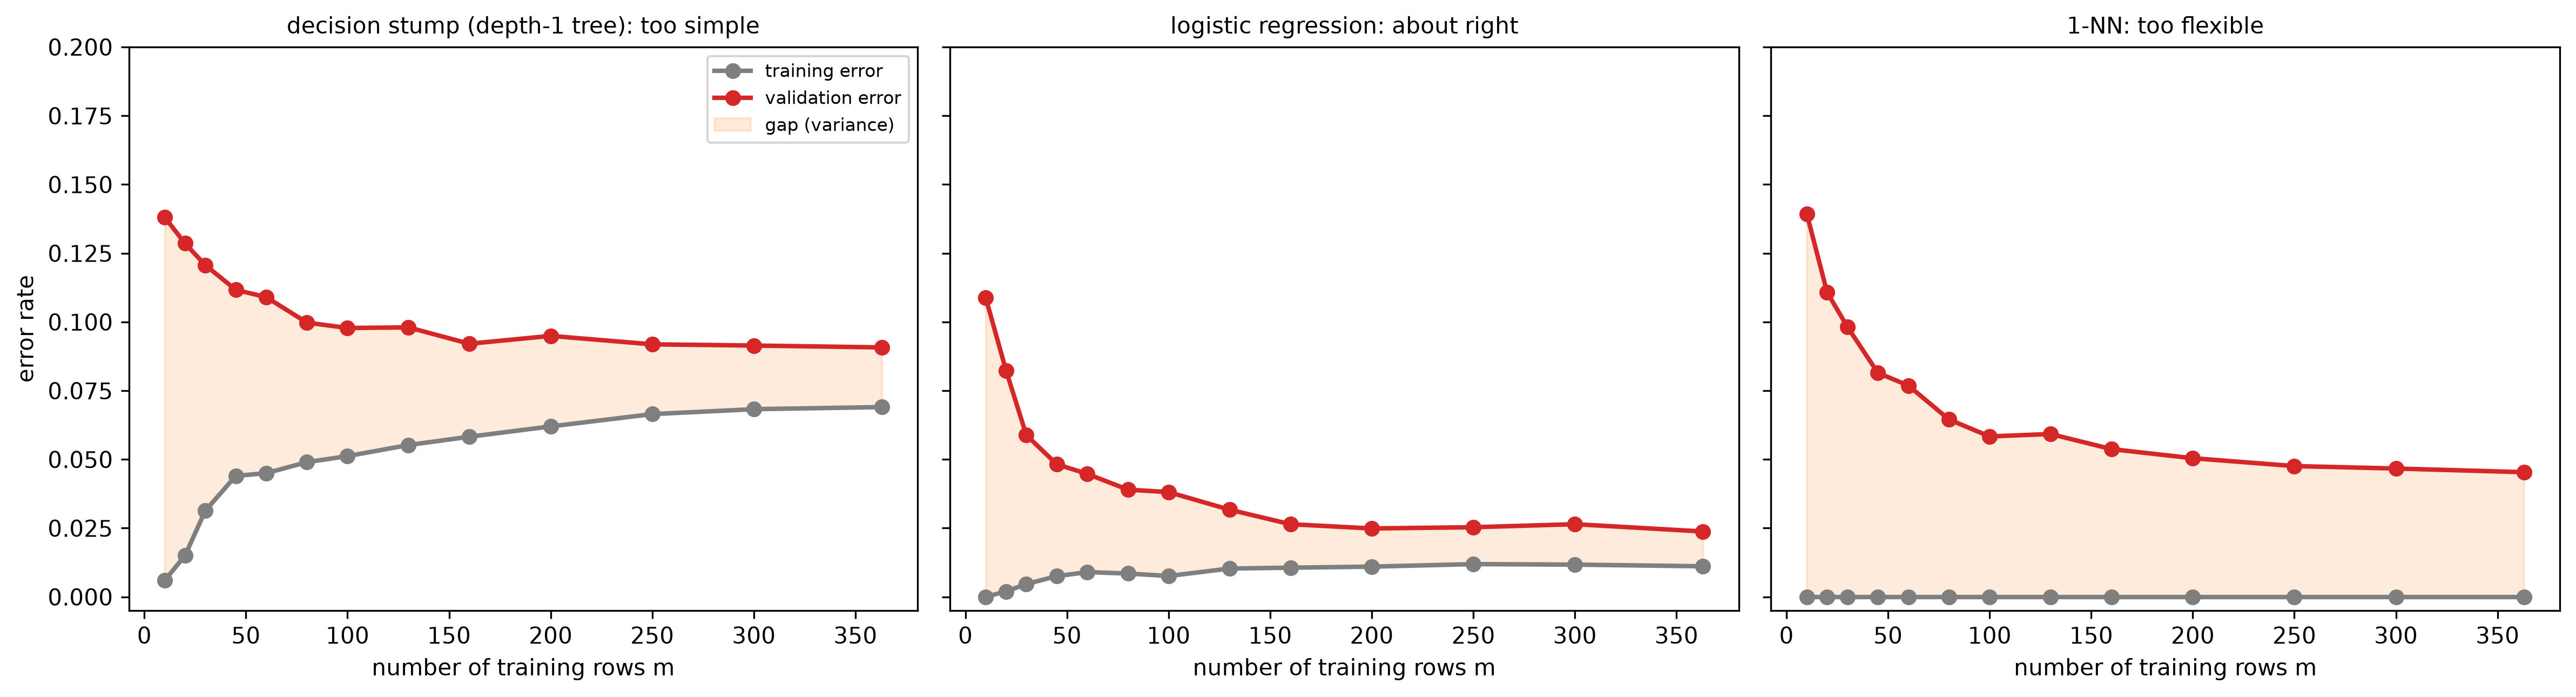

,train @ m=363,val @ m=363,gap @ m=363
decision stump (depth-1 tree): too simple,0.0690,0.0907,0.0217
logistic regression: about right,0.0111,0.0238,0.0127
1-NN: too flexible,0.0000,0.0454,0.0454


In [24]:
models_lc = {"decision stump (depth-1 tree): too simple": DecisionTreeClassifier(max_depth=1, random_state=0),
             "logistic regression: about right": logreg,
             "1-NN: too flexible": make_knn(1)}
N_LC_REPEATS = 10

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
lc_summary = {}
for ax, (name, model) in zip(axes, models_lc.items()):
    tr_all, va_all = [], []
    for r in range(N_LC_REPEATS):                                          # 10 repeats of 5-fold CV
        folds_r = stratified_kfold_indices(y_dev, 5, seed=100 + r)
        t, v = learning_curve_errors(model, X_dev, y_dev, folds_r, sizes, seed=r)
        tr_all.append(t)
        va_all.append(v)
    tr_mean = np.concatenate(tr_all, axis=1).mean(axis=1)                  # average over all 50 fits per size
    va_mean = np.concatenate(va_all, axis=1).mean(axis=1)
    lc_summary[name] = {"train @ m=363": tr_mean[-1], "val @ m=363": va_mean[-1],
                        "gap @ m=363": va_mean[-1] - tr_mean[-1]}

    ax.plot(sizes, tr_mean, "o-", color="tab:grey", lw=2, label="training error")
    ax.plot(sizes, va_mean, "o-", color="tab:red", lw=2, label="validation error")
    ax.fill_between(sizes, tr_mean, va_mean, color="tab:orange", alpha=0.15, label="gap (variance)")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("number of training rows m")
    ax.set_ylim(-0.005, 0.2)
axes[0].set_ylabel("error rate")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(lc_summary).T

**Line by line**

- `models_lc` : a dictionary from a descriptive name to an (untrained) model; `.items()` gives the pairs.
- `stratified_kfold_indices(y_dev, 5, seed=100 + r)` : a different set of stratified folds for each repeat.
- `np.concatenate(tr_all, axis=1)` : glues the ten `(13, 5)` arrays side by side into one `(13, 50)` array, so
  `.mean(axis=1)` averages over all 50 fitted models at each size.
- `ax.fill_between(sizes, tr_mean, va_mean, ...)` : shades the area *between* the two curves, the gap.
- `ax.set_ylim(-0.005, 0.2)` : the same vertical scale for all three panels, so they can be compared directly.
- The summary table records the two errors and the gap at the largest size, $m = 363$ (the full training part of
  the smallest fold).

**Reading the three panels.** Each shape has a standard diagnosis.

| model | shape of the curves | diagnosis | will more data help? | what would help |
|---|---|---|---|---|
| **decision stump** | both curves flatten out close together at a **high** level (training 0.069, validation 0.091 at $m = 363$) | **high bias** (underfitting) | **no**: the validation curve is already flat; more rows will not lower it | a more flexible model |
| **logistic regression** | validation error falls fast, then levels off at the **lowest** value of the three (about 0.025 from $m \approx 160$; 0.024 at $m = 363$); small gap (0.013) | good balance | hardly: both curves have levelled off | nothing much; this is close to what the features allow |
| **1-NN** | training error stuck at **0**; validation error falls slowly (0.045 at $m = 363$); a **large gap** | **high variance** (overfitting) | **yes**, slowly: the validation curve is still falling at the right edge | more data, or a smoother model (larger $k$) |

The stump is the clearest lesson. Its validation error is essentially flat, at about 0.09, from about 150 rows
onward: a single
question about a single feature has learned all it can, and doubling or tripling the dataset would change nothing.
Spending money on collecting more data would be wasted; the model must change. For 1-NN it is the other way around:
its training error cannot tell you anything (it is always 0), and its validation error is still improving at the
right edge of the plot.

---
## Part 7: Model selection with the validation data only, and the final test

### 7a. The protocol

Everything so far comes together in one procedure. Written out as rules:

1. **Lock away the test set first** (done in 1d).
2. **Decide the candidates in advance**: which model families, and which hyper-parameter values for each.
3. **Estimate the error of every candidate on the development set only**, with a validation set or, better, with
   cross-validation. The test set plays no part in this.
4. **Choose the candidate with the lowest validation error.**
5. **Retrain the chosen candidate on the whole development set.** The validation rows were needed for choosing; now
   that the choice is made, they are simply more training data.
6. **Evaluate that one final model on the test set, once**, and report the result. Do not go back and change anything
   because of this number: if you do, the test set has become a validation set and the number is no longer unbiased.

Our candidates: three model families from Practicals 2 and 3, each with its own complexity knob.

| family | hyper-parameter | simple end | complex end |
|---|---|---|---|
| k-NN | $k$, the number of neighbours | large $k$ | small $k$ |
| logistic regression | $C$, the inverse regularisation strength (the $1/\lambda$ of the ridge penalty in Practical 1) | small $C$ (strong penalty) | large $C$ (weak penalty) |
| decision tree | `max_depth` | shallow | deep |

Every candidate is a pipeline that starts with a `StandardScaler`, so all candidates are treated identically.
(Trees do not need scaling, and it does not change their predictions, but it does no harm.)

In [25]:
candidates = []                                      # list of (family, hyper-parameter name, value, model)
for k in [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]:
    candidates.append(("k-NN", "k", k,
                       make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))))
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    candidates.append(("logistic regression", "C", C,
                       make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=5000))))
for D in [1, 2, 3, 4, 5, 6, 8, 10]:
    candidates.append(("decision tree", "max_depth", D,
                       make_pipeline(StandardScaler(), DecisionTreeClassifier(max_depth=D, random_state=0))))

print("number of candidates:", len(candidates))
for family, hp, value, _ in candidates[:3] + candidates[10:12] + candidates[16:18]:
    print(f"  {family:<20} {hp} = {value}")
print("  ...")

number of candidates: 24
  k-NN                 k = 1
  k-NN                 k = 3
  k-NN                 k = 5
  logistic regression  C = 0.001
  logistic regression  C = 0.01
  decision tree        max_depth = 1
  decision tree        max_depth = 2
  ...


**Line by line**

- Each candidate is a **tuple** of four things: the family name, the name and value of its hyper-parameter (both only
  for printing), and the untrained model itself.
- `candidates[:3] + candidates[10:12] + candidates[16:18]` : adding lists joins them, so this prints a few examples
  from each family. `_` receives the model, which we do not print.
- `C=0.001` to `C=100` : spaced by factors of 10, because the effect of a penalty strength is felt on a log scale, as
  with $\lambda$ in Practical 1.

### 7b. Selection with a single validation set

The classic three-way split: train every candidate on the 339 training rows of 2a, score it on the 115 validation
rows, pick the lowest.

In [26]:
rows = []
for family, hp, value, model in candidates:
    fitted = clone(model).fit(X_tr, y_tr)                            # training rows only
    rows.append({"model": family, "setting": f"{hp} = {value}",
                 "validation error": error_rate(y_val, fitted.predict(X_val))})
holdout_table = pd.DataFrame(rows)

winner = holdout_table["validation error"].idxmin()
print("hold-out winner:", holdout_table.loc[winner, "model"], "with", holdout_table.loc[winner, "setting"],
      f"   validation error = {holdout_table.loc[winner, 'validation error']:.4f}")
n_tied = np.sum(holdout_table["validation error"] == holdout_table["validation error"].min())
print("number of candidates tied for first place:", n_tied)

# how stable is this choice? repeat the whole selection on 20 other train / validation splits
winners = []
for s in range(20):
    tr, va = stratified_holdout_split(y_dev, 0.25, seed=100 + s)
    errs = [error_rate(y_dev[va], clone(m).fit(X_dev[tr], y_dev[tr]).predict(X_dev[va]))
            for _, _, _, m in candidates]
    fam, hp, val, _ = candidates[int(np.argmin(errs))]
    winners.append(f"{fam}, {hp} = {val}")
print("\nwinners over 20 different validation splits:")
print(pd.Series(winners).value_counts().to_string())

hold-out winner: logistic regression with C = 0.1    validation error = 0.0087
number of candidates tied for first place: 2

winners over 20 different validation splits:
logistic regression, C = 1      8
logistic regression, C = 0.1    3
k-NN, k = 5                     3
k-NN, k = 9                     2
logistic regression, C = 10     2
k-NN, k = 3                     1
k-NN, k = 7                     1


**Line by line**

- The first loop is hold-out validation for all 24 candidates: fit on `X_tr`, score on `X_val`.
- `idxmin()` returns the **first** row with the smallest error. When several candidates tie, the one listed first wins,
  which is an arbitrary choice.
- `n_tied` : counts how many candidates share the minimum. With 115 validation rows, errors can only be multiples
  of $1/115$, so ties are common.
- The second loop repeats the entire selection on 20 other splits of the development set and records the winner
  each time. The inner list comprehension trains and scores all 24 candidates on one split.
- `pd.Series(winners).value_counts()` : how many times each candidate won.

**Reading the output.** On the split of 2a the winner is logistic regression with $C = 0.1$, with a validation error
of 0.0087: **one** mistake out of 115, shared with one other candidate. That number looks wonderful, and it is too
good to be true. It is the *smallest* of 24 noisy numbers, and the smallest of many noisy numbers is almost always
lucky. Section 7f shows how far this optimism can go.

The winner also depends heavily on the split. Across 20 other splits the "best model" changes between families and
between hyper-parameter values: logistic regression with $C = 1$ wins 8 times, $C = 0.1$ and 5-NN 3 times each, and
four other candidates win once or twice. This is 2b's noise problem again, now at the level of *decisions*: with one
validation split of 115 rows we cannot reliably tell apart candidates whose true errors differ by a percent or two.
Cross-validation is the remedy.

### 7c. Selection with stratified 5-fold cross-validation

The same 24 candidates, now each evaluated by our own `cross_val_errors` on the stratified folds `folds_bc` from
Part 5. Every development row is used for validation once, and the test set is still untouched.

In [27]:
rows = []
for family, hp, value, model in candidates:
    _, va_e = cross_val_errors(model, X_dev, y_dev, folds_bc)
    rows.append({"model": family, "setting": f"{hp} = {value}",
                 "CV error": va_e.mean(), "std over folds": va_e.std()})
cv_table = pd.DataFrame(rows)

cv_errors = cv_table["CV error"].to_numpy()
tied = np.flatnonzero(np.isclose(cv_errors, cv_errors.min()))    # every candidate (numerically) tied for best
print("candidates tied for the lowest CV error:", [cv_table.loc[i, "setting"] for i in tied])
print("their CV errors printed with 17 digits :", [f"{cv_errors[i]:.17f}" for i in tied])
cv_table["CV error"] = cv_table["CV error"].round(12)             # remove the rounding dust: ties become exact

best_idx = int(tied[0])                                          # ties broken by list order, like GridSearchCV
best_family, best_hp, best_value, best_model = candidates[best_idx]
best_cv_error = cv_table.loc[best_idx, "CV error"]
print(f"CV winner: {best_family} with {best_hp} = {best_value},   CV error = {best_cv_error:.4f}\n")

print("best setting of each family:")
print(cv_table.loc[cv_table.groupby("model")["CV error"].idxmin()].to_string(index=False))
print("\nthe ten best candidates overall:")
cv_table.sort_values("CV error", kind="stable").head(10)

candidates tied for the lowest CV error: ['C = 0.1', 'C = 10']
their CV errors printed with 17 digits : ['0.02862026862026863', '0.02862026862026862']
CV winner: logistic regression with C = 0.1,   CV error = 0.0286

best setting of each family:
              model       setting  CV error  std over folds
      decision tree max_depth = 3    0.0705          0.0148
               k-NN         k = 5    0.0330          0.0098
logistic regression       C = 0.1    0.0286          0.0112

the ten best candidates overall:


,model,setting,CV error,std over folds
12,logistic regression,C = 0.1,0.0286,0.0112
14,logistic regression,C = 10,0.0286,0.0149
13,logistic regression,C = 1,0.0330,0.0230
2,k-NN,k = 5,0.0330,0.0098
1,k-NN,k = 3,0.0374,0.0111
15,logistic regression,C = 100,0.0374,0.0149
4,k-NN,k = 9,0.0375,0.0132
3,k-NN,k = 7,0.0397,0.0112
6,k-NN,k = 15,0.0419,0.0109
5,k-NN,k = 11,0.0419,0.0178


**Line by line**

- The loop is the same as in 7b, with `cross_val_errors` in place of a single fit and score.
- **Ties.** Two candidates can make exactly the same number of mistakes, yet the computer, adding up five fold errors
  that are fractions like $3/91$, can end up with two numbers that differ only in the 17th digit. The second printed
  line shows exactly this. A plain `idxmin()` would then crown one of them because of rounding dust, which is
  meaningless. So:
  - `cv_table["CV error"].to_numpy()` : the column as a plain NumPy array.
  - `np.isclose(cv_errors, cv_errors.min())` : `True` wherever an error equals the minimum up to tiny
    floating-point rounding; `np.flatnonzero` turns that into the positions of all tied candidates.
  - `.round(12)` : rounds the column to 12 decimals, which removes the dust, so the tied rows really are equal in the
    tables below.
  - `best_idx = int(tied[0])` : among the tied candidates, take the one listed **first**. `GridSearchCV` breaks ties
    the same way, which 7d confirms.
- `candidates[best_idx]` : the position of the best row in `cv_table` is also its position in the candidate list,
  because both were built in the same order. Unpacking the tuple gives us the winning model object.
- `cv_table.groupby("model")["CV error"].idxmin()` : for each family separately, the row with the smallest CV error.
  `.loc[...]` then picks those rows, giving one "best of family" row per model family.
- `.sort_values("CV error", kind="stable").head(10)` : the table sorted from best to worst, first ten rows. A
  **stable** sort keeps rows with equal values in their original order, so tied candidates stay in list order.

**Reading the output.**

- **Logistic regression** has the lowest CV error, 0.0286, which corresponds to 13 mistakes out of 454 development
  rows. Two settings reach it: $C = 0.1$ and $C = 10$. The tie is broken in favour of $C = 0.1$ because it is listed
  first. That is also the choice we would make on principle: $C = 0.1$ is the **stronger penalty**, i.e. the simpler
  model, and between two equally good models we prefer the simpler one.
- The best k-NN ($k = 5$, CV error 0.0330, 15 mistakes) is two mistakes worse, and the best decision tree
  (depth 3, 0.0705, 32 mistakes) is clearly worse than both. Look at the tree rows in the table: depth 1 underfits
  (0.095), and deeper trees do not help (0.07 to 0.08) because a tree's boundary is made of axis-parallel steps, a
  poor shape for a boundary that depends smoothly on many features at once.
- Within logistic regression the pattern of Part 5 appears again: $C = 0.001$ (penalty far too strong) underfits
  badly (0.119), $C = 100$ (almost no penalty) is a little worse (0.037), and the best values are in between.
- The "std over folds" column (around 0.01 to 0.02) is a reminder that the top few candidates are close: the top
  four are within two mistakes of each other. The ranking among them is not certain, but, unlike the single-split
  selection of 7b, it is based on all 454 rows.

### 7d. Checking the whole selection against `GridSearchCV`

scikit-learn packages steps 3 and 4 of the protocol (evaluate every candidate by cross-validation, pick the best)
in `GridSearchCV`. We give it the same candidates, described as a **parameter grid**, and our own folds.

In [28]:
search_pipe = Pipeline([("scale", StandardScaler()), ("clf", KNeighborsClassifier())])   # "clf" is swapped below
param_grid = [
    {"clf": [KNeighborsClassifier()], "clf__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]},
    {"clf": [LogisticRegression(max_iter=5000)], "clf__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    {"clf": [DecisionTreeClassifier(random_state=0)], "clf__max_depth": [1, 2, 3, 4, 5, 6, 8, 10]},
]
search = GridSearchCV(search_pipe, param_grid, cv=folds_bc, scoring="accuracy")
search.fit(X_dev, y_dev)                                     # 24 candidates x 5 folds = 120 fits, then 1 refit

lib_cv_error = 1 - search.cv_results_["mean_test_score"]     # one CV error per candidate, same order as ours
print("CV errors identical to ours      :", np.allclose(lib_cv_error, cv_table["CV error"]))
print("same winner                      :", search.best_index_ == best_idx)
print("GridSearchCV's best parameters   :", search.best_params_)
print(f"GridSearchCV's best CV error     : {1 - search.best_score_:.4f}   (ours: {best_cv_error:.4f})")

CV errors identical to ours      : True
same winner                      : True
GridSearchCV's best parameters   : {'clf': LogisticRegression(max_iter=5000), 'clf__C': 0.1}
GridSearchCV's best CV error     : 0.0286   (ours: 0.0286)


**Line by line**

- `Pipeline([("scale", ...), ("clf", ...)])` : like `make_pipeline`, but we choose the step **names** ourselves.
  Names are needed to refer to a step from the parameter grid.
- `param_grid` : a **list of dictionaries**, one per model family.
  - `"clf": [KNeighborsClassifier()]` says "replace the step called `clf` with this model".
  - `"clf__n_neighbors": [...]` says "and try these values of its `n_neighbors` setting". The **double underscore**
    means "the setting `n_neighbors` of the step `clf`".
  - `GridSearchCV` tries every combination within each dictionary, in the order the dictionaries are listed, which
    is the same order as our `candidates` list.
- `cv=folds_bc` : our own stratified folds, so the library sees exactly the same splits as our loop in 7c.
- `search.cv_results_` : a dictionary of result arrays, one entry per candidate. `mean_test_score` is the average
  validation accuracy over the folds (scikit-learn calls every held-out fold a "test" fold, but in our vocabulary it
  is a validation fold).
- `search.best_index_`, `best_params_`, `best_score_` : the position, settings and CV accuracy of the winner.
- After the search, `GridSearchCV` automatically performs step 5 of the protocol: it **refits** the winner on all the
  rows it was given (here, the whole development set) and stores it as `search.best_estimator_`.

**Reading the output.** All 24 CV errors are identical to ours, and the same candidate wins. The library's model
selection is exactly the loop we wrote in 7c.

### 7e. The final model and its unbiased test error

The choice is made. Now, and only now, steps 5 and 6: retrain the winner on all 454 development rows and evaluate it,
**once**, on the 115 test rows locked away in 1d.

A test error is itself an estimate from a finite sample, so we report it with its **standard error**
$\sqrt{p(1-p)/n_{\text{test}}}$ (Practical 3, 2c) and an approximate 95% interval $p \pm 1.96 \times \text{SE}$.

In [ ]:
final_model = clone(best_model).fit(X_dev, y_dev)            # step 5: retrain on ALL development rows

same_as_library = np.array_equal(final_model.predict(X_dev), search.best_estimator_.predict(X_dev))
print("our final model = GridSearchCV's refitted model (same predictions on the dev set):", same_as_library)

# step 6: the ONE AND ONLY use of the test set 
y_test_pred = final_model.predict(X_test)

test_error = error_rate(y_test, y_test_pred)
n_mistakes = int(np.sum(y_test_pred != y_test))
se_test = np.sqrt(test_error * (1 - test_error) / len(y_test))
low, high = max(0.0, test_error - 1.96 * se_test), test_error + 1.96 * se_test

print(f"\nfinal model : {best_family} with {best_hp} = {best_value}")
print(f"CV error on the development set (used for CHOOSING) : {best_cv_error:.4f}")
print(f"TEST error, unbiased (used for REPORTING)           : {test_error:.4f}"
      f"   = {n_mistakes} mistakes out of {len(y_test)} test tumours")
print(f"standard error {se_test:.4f},  approximate 95% interval [{low:.4f}, {high:.4f}]\n")

pd.crosstab(pd.Series(class_names_bc[y_test], name="true diagnosis"),
            pd.Series(class_names_bc[y_test_pred], name="predicted diagnosis"))

our final model = GridSearchCV's refitted model (same predictions on the dev set): True

final model : logistic regression with C = 0.1
CV error on the development set (used for CHOOSING) : 0.0286
TEST error, unbiased (used for REPORTING)           : 0.0348   = 4 mistakes out of 115 test tumours
standard error 0.0171,  approximate 95% interval [0.0013, 0.0683]



predicted diagnosis,benign,malignant
true diagnosis,,
benign,71,1
malignant,3,40


**Line by line**

- `clone(best_model).fit(X_dev, y_dev)` : a fresh copy of the winning candidate, trained on all 454 development rows.
- `same_as_library` : compares our final model with the one `GridSearchCV` refitted in 7d, on the **development**
  rows. They make the same predictions, so our step 5 is exactly what the library does.
- `final_model.predict(X_test)` : the line this whole practical has been protecting. It is the only place in Parts 1 to
  7 where `X_test` is used.
- `max(0.0, ...)` : an error rate cannot be negative, so the lower end of the interval is cut at 0.
- `pd.crosstab(a, b)` : counts every combination of true and predicted class, i.e. the **confusion table** of
  Practical 2. Wrapping the arrays in `pd.Series(..., name=...)` gives the rows and columns readable titles.

**Reading the output.**

- The final model makes **4 mistakes on the 115 test tumours**, a test error of 0.0348. The confusion table shows
  which kind: 3 malignant tumours called benign (missed cancers) and 1 benign tumour called malignant (a false alarm);
  40 of the 43 malignant and 71 of the 72 benign tumours are classified correctly. In a real screening application
  these two mistakes have very different costs, which is exactly the cost-sensitive decision problem of Practical 3,
  Exercise 1.
- The test error (0.035) is slightly **above** the CV error of the winner (0.029). That is the direction 7f predicts:
  the CV error of the chosen model is a little optimistic because it was used to choose. Here the difference is about
  one test mistake, well within the noise. Notice how **wide** the interval is, from 0.001 to 0.068: with only 115
  test rows, a single mistake more or less moves the error by almost 0.01. The test error is unbiased, not
  precise. This is the price of a small dataset, and it is why the test set should not be made too small.
- This number is what goes in the report. We will not use `X_test` again.

### 7f. Why the test set has to stay untouched: the winner's curse

Why not simply report the CV error of the winner (0.0286 above) and skip the test set? Because the winner was chosen
**for having the smallest validation error**, and the smallest of many noisy numbers is systematically too small.

The effect is easiest to see in a world where we know the truth, so, in the spirit of Practical 3, we build one. The
features are pure noise and the labels are fair coin flips, completely unrelated to the features. **Every** classifier
in this world has a true error rate of exactly 0.5 (the Bayes error rate is 0.5: there is nothing to learn). We then
do what a careless analyst might do: try 100 different k-NN models (random values of $k$, random subsets of 3 of the
30 features), pick the one with the lowest validation error, and look at how it does on a large fresh test set.

true error of EVERY model                  : 0.5
average validation error of the 100 models : 0.4813
validation error of the winner             : 0.3600   <- looks like real learning!
TEST error of the winner (10 000 new rows) : 0.4978   <- the truth


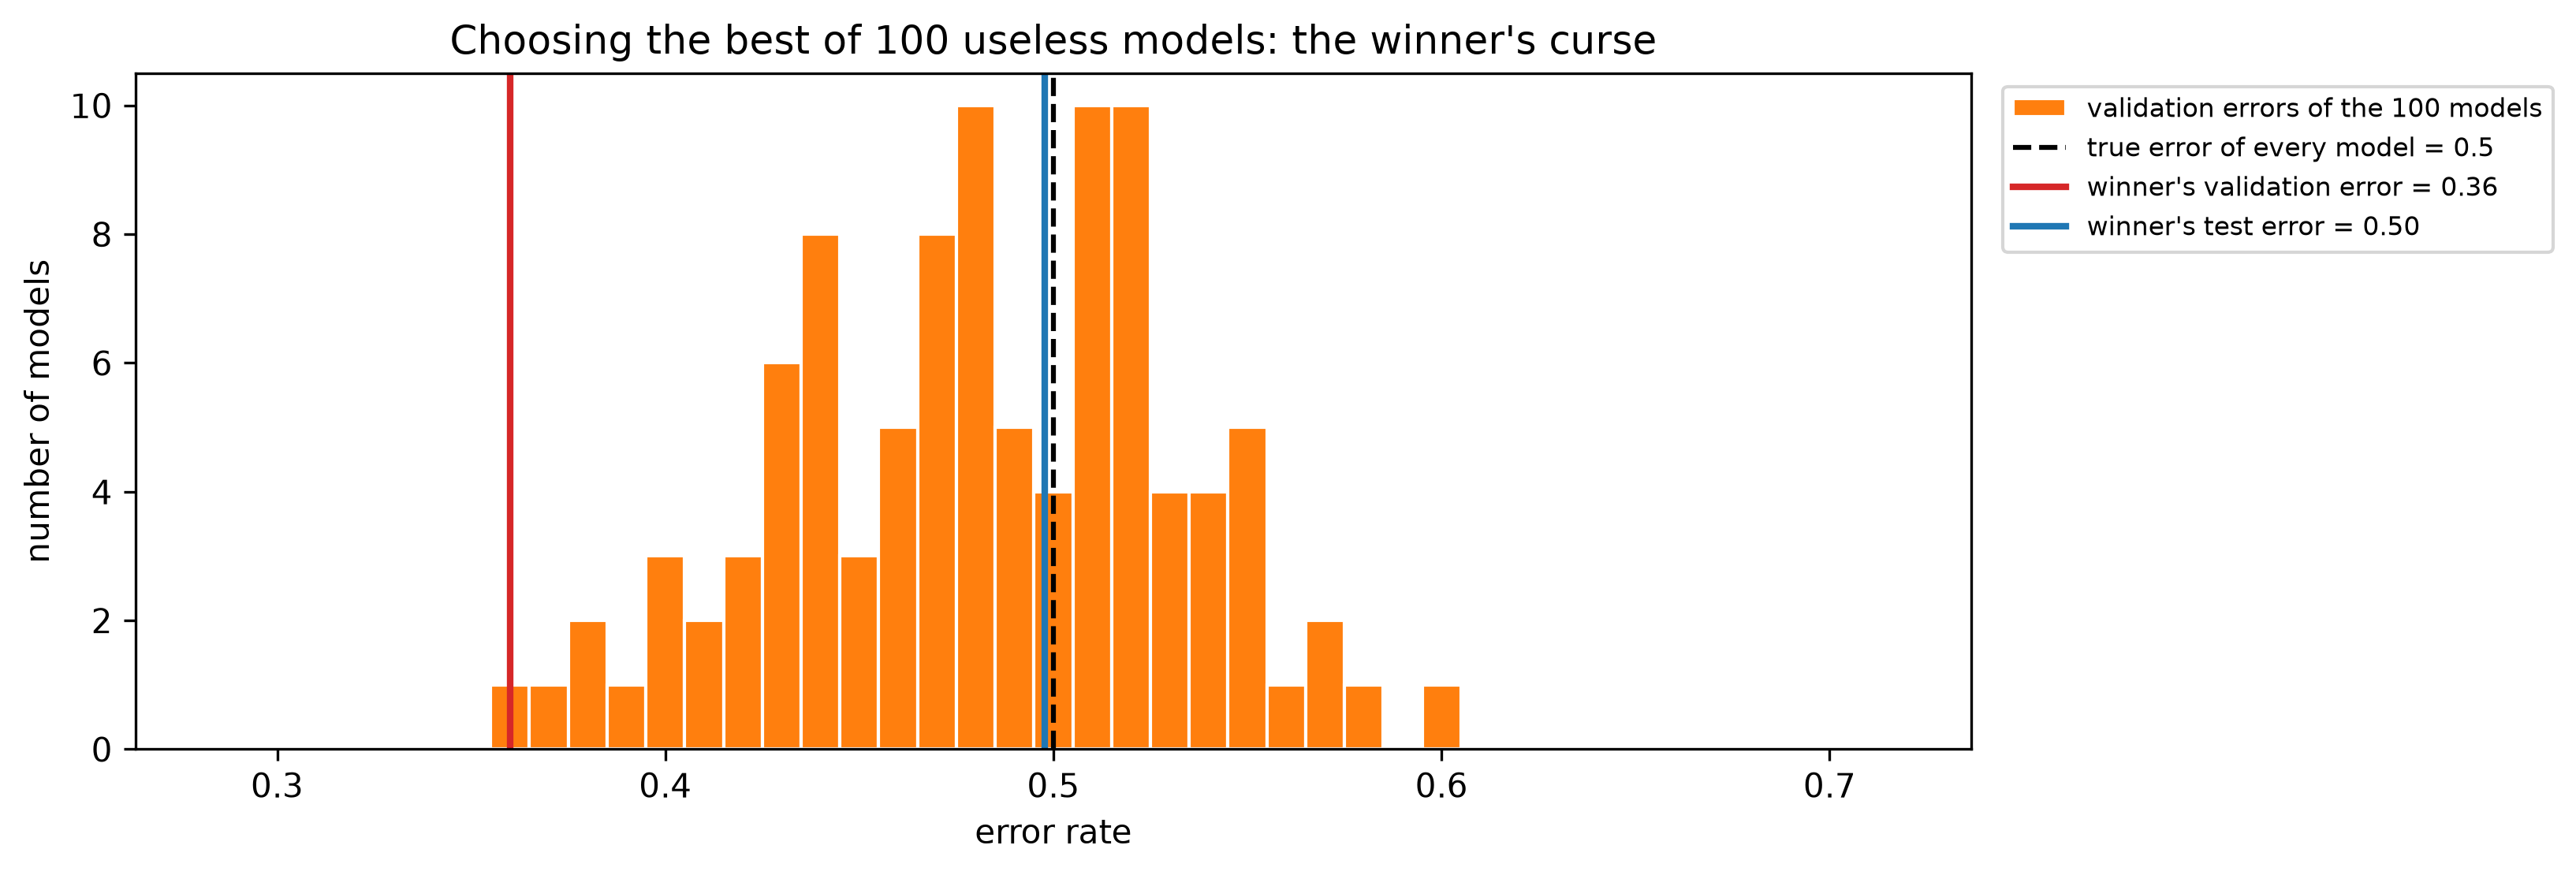

In [30]:
N_TR, N_VA, N_TE, D_NOISE = 200, 100, 10_000, 30
X_noise = rng.normal(size=(N_TR + N_VA + N_TE, D_NOISE))        # features: pure noise
y_noise = rng.integers(0, 2, size=N_TR + N_VA + N_TE)            # labels: fair coin flips, unrelated to X
Xn_tr, yn_tr = X_noise[:N_TR], y_noise[:N_TR]
Xn_va, yn_va = X_noise[N_TR:N_TR + N_VA], y_noise[N_TR:N_TR + N_VA]
Xn_te, yn_te = X_noise[N_TR + N_VA:], y_noise[N_TR + N_VA:]

noise_val, noise_test = [], []
for i in range(100):                                             # 100 candidate models
    feats = rng.choice(D_NOISE, size=3, replace=False)           # a random subset of 3 features
    k = int(rng.choice([1, 3, 5, 9, 15, 25]))                    # a random number of neighbours
    m = make_knn(k).fit(Xn_tr[:, feats], yn_tr)
    noise_val.append(error_rate(yn_va, m.predict(Xn_va[:, feats])))
    noise_test.append(error_rate(yn_te, m.predict(Xn_te[:, feats])))
noise_val, noise_test = np.array(noise_val), np.array(noise_test)

w = int(np.argmin(noise_val))                                    # the "best" model by validation error
print(f"true error of EVERY model                  : 0.5")
print(f"average validation error of the 100 models : {noise_val.mean():.4f}")
print(f"validation error of the winner             : {noise_val[w]:.4f}   <- looks like real learning!")
print(f"TEST error of the winner (10 000 new rows) : {noise_test[w]:.4f}   <- the truth")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.hist(noise_val, bins=np.arange(0.285, 0.72, 0.01), color="tab:orange", edgecolor="white",
        label="validation errors of the 100 models")
ax.axvline(0.5, color="black", ls="--", lw=1.5, label="true error of every model = 0.5")
ax.axvline(noise_val[w], color="tab:red", lw=2, label=f"winner's validation error = {noise_val[w]:.2f}")
ax.axvline(noise_test[w], color="tab:blue", lw=2, label=f"winner's test error = {noise_test[w]:.2f}")
ax.set_xlabel("error rate")
ax.set_ylabel("number of models")
ax.set_title("Choosing the best of 100 useless models: the winner's curse")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))   # legend OUTSIDE, right of the axes
plt.tight_layout()
plt.show()

**Line by line**

- `rng.normal(size=(n, 30))` : a matrix of independent standard normal numbers; `rng.integers(0, 2, size=n)` : fair
  0/1 coin flips. Nothing links the two, so no model can do better than guessing.
- The rows are cut into 200 training, 100 validation and 10 000 test rows. The huge test set makes each test error very
  precise (standard error about 0.005).
- `rng.choice(30, size=3, replace=False)` : three **different** feature numbers out of 30.
- Every candidate is trained on the same 200 training rows and scored on the same 100 validation rows and the same
  10 000 test rows.
- `np.argmin(noise_val)` : the position of the smallest validation error, the model a validation-based selection
  would pick.
- `bbox_to_anchor=(1.01, 1)` together with `loc="upper left"` : places the upper-left corner of the legend just to
  the right of the plot area, so the legend covers neither the bars nor the vertical lines.

**Reading the plot.**

- The 100 validation errors scatter around the true value 0.5 with a standard deviation of about
  $\sqrt{0.25/100} = 0.05$, simply because 100 validation rows is a small sample.
- The winner is, by construction, the **luckiest** of the 100. Its validation error is 0.36, far below 0.5, and
  anyone who reported it would claim a classifier that is right 64% of the time, beating coin-flipping by a wide
  margin.
- On 10 000 fresh rows the winner's error is 0.498, right back at 0.5. **It was never better; it was selected for being
  lucky on the validation rows.**

This is called **selection bias** or the **winner's curse**, and it is the reason for rule 6 of the protocol. Once a
set of rows has been used to *choose*, the error measured on those rows is optimistic for the chosen model. That
holds for a single validation set and for cross-validation alike. Only rows that played **no part** in any choice
give an unbiased estimate, and that is precisely what the locked test set is. On the real data in 7c–7e the effect
was mild (24 candidates, a genuine signal, and five folds of averaging), but it is always there, and it grows with the
number of candidates you try and shrinks with the size of the validation data. Remember the single-split winner of
7b, with a validation error of 0.0087 (one mistake): that is the same curse on a smaller scale. No model in 7c comes
close to that number under cross-validation, and the final test error is four times larger.

---
## Summary

| procedure | what it does | our code | checked against | result of the check |
|---|---|---|---|---|
| hold-out split | shuffle the row numbers, cut off a fraction | `holdout_split` | `train_test_split` | identical rows |
| stratified hold-out | hold-out inside every class, then merge | `stratified_holdout_split` | `train_test_split(stratify=y)` | same class proportions |
| $K$-fold CV (splits) | $K$ folds, every row validated exactly once | `kfold_indices` | `KFold` | identical folds |
| $K$-fold CV (loop) | fit on $K-1$ folds, score on the $K$-th, average | `cross_val_errors` | `cross_validate` | identical fold errors |
| stratified $K$-fold | deal the sorted labels round-robin (how many), shuffle within class (which) | `stratified_kfold_indices` | `StratifiedKFold` | identical folds, 2 and 3 classes |
| complexity curve | training and validation error against a complexity knob | `knn_curve`, `tree_curve` | Practical 3 | the U-shape, on real data |
| learning curve | training and validation error against training-set size | `learning_curve_errors` | `learning_curve` | identical errors |
| model selection | lowest CV error, development rows only | `cv_table` | `GridSearchCV` | identical CV errors, same winner |
| final assessment | refit the winner on all development rows, score the test set once | `final_model` | `search.best_estimator_` | same model |

**The one sentence version:** fit on training rows, choose on validation rows (preferably by stratified $K$-fold
cross-validation, which uses every development row and is far less noisy than a single split), and report the error of
the one chosen model on test rows that were locked away before anything else happened, because the training error
always flatters complex models and the validation error always flatters the model it chose.

**How this connects to the previous practicals.** Practical 1 built the feature matrix $X$ and the target $y$ and fitted
models to them; this practical splits the rows of that same matrix into roles. Practical 2 estimated class
proportions from data; stratification is what keeps those proportions intact in every fold. Practical 3 defined the
generalisation error (the risk), showed the bias–variance U-curve and ended with *"in real life you must hold some
back"*: here the U-curve reappears as the validation curve of Part 5, the bias and variance diagnoses reappear in the
learning curves of Part 6, and holding back is done properly, twice, once for choosing and once for reporting.

---
# Exercises

Five exercises, roughly in order of difficulty. Write your code in the empty cell below each one. Everything you
need is already defined or imported above, except where an exercise tells you to import one extra item.

**Before you start, a habit worth keeping.** Every time you look at an error number, ask two questions: *which rows
was it computed on?* and *were those rows used to choose anything?* A training error says little; a validation
error is honest only for models that were not chosen with it; only a test error of a model chosen without the test
set is unbiased.

## Exercise 1: Leave-one-out cross-validation

The most extreme choice of $K$ is $K = n$: every fold holds a single row. This is **leave-one-out cross-validation
(LOOCV)**.

1. Write `loo_indices(n)` that returns the $n$ pairs `(train_idx, val_idx)`, where `val_idx` contains a single row.
   Check it with `check_partition`, and check it against scikit-learn: `from sklearn.model_selection import
   LeaveOneOut` and compare with `list(LeaveOneOut().split(X_dev))` using `same_folds`.
2. Compute the LOOCV error of 5-NN on the development set with `cross_val_errors` (454 fits). Compare it with the mean
   of the 5-fold estimates in 3d (`cv_estimates`), and with 10-fold CV repeated over 50 shuffles.
3. Repeating 5-fold CV with different shuffles gave different answers (3d). What happens if you "repeat" LOOCV with
   different shuffles? Why?
4. Time 5-fold CV, 10-fold CV and LOOCV with `import time` and `time.perf_counter()`. How many model fits does each
   need? Which would you use for a dataset with 50 rows, and which for one with 5 million rows? Explain.
5. For LOOCV, each fold's validation error is either 0 or 1. Explain why the "std over folds" band that we drew in
   Part 5 is useless for LOOCV.

In [31]:
# Your code for Exercise 1

## Exercise 2: Stratification when one class is rare

In the breast-cancer data the smaller class is still 37% of the rows. Make it rare and watch plain $K$-fold fail.

1. Build a **rare-class** development set that keeps all benign rows but only the first 20 malignant rows of `X_dev`:
   `keep = np.concatenate([np.flatnonzero(y_dev == 1), np.flatnonzero(y_dev == 0)[:20]])`, then shuffle `keep` with
   `rng.permutation`. What fraction of this new set is malignant?
2. Make 10 plain folds (`kfold_indices`, any seed) and 10 stratified folds (`stratified_kfold_indices`). For each,
   print the number of malignant rows in every validation fold. Then repeat the plain version for 200 seeds and
   report the **average number of folds that contain no malignant row at all**.
3. For 5-NN, compute in every validation fold both the error rate and the **recall** of the malignant class: the
   fraction of the fold's malignant rows that are predicted malignant. What goes wrong with recall in a fold that has
   no malignant rows? How does stratification fix it?
4. Compare the spread (std over 200 shuffles) of the plain and the stratified CV error estimate on the rare-class set.
   Is the difference bigger or smaller than on the original data (Part 4d)?
5. In two or three sentences: why does stratification matter more the rarer the class is?

In [32]:
# Your code for Exercise 2

## Exercise 3: Model selection for regression, end to end

Repeat the whole protocol of Part 7 on the **Diabetes** data, whose test set (`Xr_test`, `yr_test`) has been
locked since section 1d.

1. Build a candidate list with three families: `DecisionTreeRegressor` with `max_depth` from 1 to 8;
   `KNeighborsRegressor` (import it from `sklearn.neighbors`, and put it in a pipeline with a `StandardScaler`) with
   $k \in \{1, 3, 5, 10, 20, 40, 80\}$; and **ridge regression** from Practical 1 (`from sklearn.linear_model import
   Ridge`) with `alpha` in `np.logspace(-3, 3, 7)` (scikit-learn calls the penalty $\lambda$ `alpha`).
2. Evaluate every candidate with `cross_val_errors(..., folds_db, error_fn=mse)` on the development set only. Show the
   ten best in a table, and the best of each family. Compare them with the baseline of 5c.
3. Draw learning curves (with `learning_curve_errors` and `error_fn=mse`) for the best candidate of each family. For
   which family would more data help most?
4. Refit the winner on all of `Xr_dev` and evaluate it **once** on `Xr_test`. Report the test MSE, its
   **coefficient of determination** $R^2 = 1 - \text{MSE} / \text{Var}(y_{\text{test}})$, and compare with the winner's
   CV error.
5. We used plain $K$-fold here. Could a regression problem be stratified? Try this: cut `yr_dev` into 5 groups by its
   quantiles (`np.digitize(yr_dev, np.quantile(yr_dev, [0.2, 0.4, 0.6, 0.8]))`) and pass the group numbers to
   `stratified_kfold_indices`. Does it make the CV estimate less noisy over 100 shuffles?

In [33]:
# Your code for Exercise 3

## Exercise 4: Data leakage

**Leakage** means that information from the validation or test rows sneaks into training. The result is always an
over-optimistic error. This exercise builds the most famous example.

1. Create a world with no signal and many features: `X_leak = rng.normal(size=(200, 2000))` and
   `y_leak = rng.integers(0, 2, size=200)`. Every classifier has a true error of 0.5 here.
2. **The wrong way.** Using **all 200 rows**, compute the correlation of every feature with `y_leak` and keep the 20
   features with the largest absolute correlation. Then run stratified 5-fold CV of `make_knn(5)` (or logistic
   regression) on those 20 features. Report the CV error.
3. **The right way.** Do the feature selection **inside** the cross-validation loop: for each fold, compute the
   correlations using the **training rows of that fold only**, keep the top 20, fit, and score on the validation fold.
   Report the CV error. (You will need to write your own loop, modelled on `cross_val_errors`.)
4. Explain the difference between the two numbers. Which rule of this practical does the wrong way break? Why does
   putting `StandardScaler` *inside* the pipeline (section 0c) protect us from a milder version of the same mistake?
5. *(Optional)* On the real breast-cancer data, standardise `X_dev` once using all its rows, then run k-NN
   cross-validation without a scaler in the pipeline. Compare with the correct pipeline version. Is this leak
   noticeable here? Why is scaling a much milder leak than feature selection?

*Hint for step 2:* standardise the columns and `y`, and the correlations are a single matrix–vector product
(Practical 1): `corr = ((X - X.mean(0)) / X.std(0)).T @ ((y - y.mean()) / y.std()) / len(y)`. Then
`np.argsort(-np.abs(corr))[:20]` gives the 20 strongest.

In [34]:
# Your code for Exercise 4

## Exercise 5: The one-standard-error rule and nested cross-validation

1. **The one-standard-error rule.** In 5a the validation curve was flat near its minimum. For the best $k$, compute
   the standard error of its CV error as `val std / sqrt(K)` from `knn_curve`. Then choose the **largest** $k$ (the
   simplest model) whose CV error is at most `best CV error + standard error`. Which $k$ does the rule choose? Apply
   the same rule to the tree depths in `tree_curve`. Why might a simpler model be preferable when the errors are
   statistically indistinguishable?
2. **Nested cross-validation.** In 7c the CV error of the winner (0.0286) was used both to choose the winner and
   as its score, so 7f tells us it is optimistic. Nested CV estimates the error of the **whole procedure** "select by
   CV, then refit" without touching the test set:
   - Outer loop: `stratified_kfold_indices(y_dev, 5, seed=1)`.
   - For each outer fold: on the outer **training** rows only, run the full selection of 7c (all 24 candidates, inner
     stratified 5-fold CV made with `stratified_kfold_indices(y_outer_train, 5, seed=0)`), refit the inner winner on
     all outer training rows, and compute its error on the outer validation fold.
   - Report the winner of each outer fold (do they agree?) and the average outer error.
3. Check your nested CV against the library: `cross_validate(GridSearchCV(search_pipe, param_grid,
   cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="accuracy"), X_dev, y_dev,
   cv=stratified_kfold_indices(y_dev, 5, seed=1), scoring="accuracy")`. The outer errors should be identical to yours.
   (Why do the inner folds match? Think about what 4c proved.)
4. Put three numbers side by side: the best CV error of 7c, your nested CV estimate, and the test error of 7e. Which
   of the first two is the honest estimate of what the test error will be? How many model fits did nested CV need?

In [35]:
# Your code for Exercise 5